# BSM: sterile neutrinos

Four- and five-flavour systems, where the extra states do not couple to the weak interaction.

The machinery is unchanged; only the dimension of the Hamiltonian and the number of mixing angles and phases grow.

In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# Mag(nu)s is imported as an installed package -- from the repository root,
# 'pip install -e .' (add [plot] for magnus.plotting). No sys.path juggling.
import magnus.oscprob as oscprob
import magnus.hamiltonians as hamiltonians
import magnus.matter as matter
import magnus.earth as earth
import magnus.globaldefs as gd
import magnus.plotting as plotting

Mag$\nu$s has no intrinsic limitation on the number of neutrino flavors contained in the system that it computes oscillation probabilities for.  However, it is distributed with ready-made mixing matrices and Hamiltonians for the two most popular scenarios: 3+1 (three active neutrinos plus one sterile neutrino) and 3+2.  Users can add their own mixing matrices and Hamiltonians for larger systems by following the same structure used when writing the modules `hamiltonians4nu` and `hamiltonians5nu` that are distributed with Mag$\nu$s.

Below, we show examples mainly for the 3+1 system, and one example for the 3+2 system.

# 0. Helper functions and definitions

In [2]:
def flavor_index_to_str(nu_l):
    return {gd.NUE: 'e', gd.NUMU: 'mu', gd.NUTAU: 'tau',
            gd.NUS1: 's1', gd.NUS2: 's2'}[nu_l]


def sterile_annotations(N):
    """The active-sterile parameters a figure was made with.

    Stacked upward from the bottom-left corner, so the number of lines follows
    from the number of sterile states rather than from hand-written positions.
    """
    if N == 1:
        lines = [r'$s_{14} = $ ' + str(s14) + r', $\delta_{14} = $ ' + str(d14),
                 r'$s_{24} = $ ' + str(s24) + r', $\delta_{24} = $ ' + str(d24),
                 r'$s_{34} = $ ' + str(s34),
                 r'$\Delta m_{41}^2 =$ ' + str(D41) + r' eV$^2$']
    else:
        lines = [r'$s_{14} = $ ' + str(s14) + r', $\delta_{14} = $ ' + str(d14),
                 r'$s_{15} = $ ' + str(s15) + r', $\delta_{15} = $ ' + str(d15),
                 r'$s_{24} = $ ' + str(s24) + r', $\delta_{24} = $ ' + str(d24),
                 r'$s_{25} = $ ' + str(s25),
                 r'$s_{34} = $ ' + str(s34) + r', $s_{35} = $ ' + str(s35),
                 r'$\Delta m_{41}^2 =$ ' + str(D41) + r' eV$^2$',
                 r'$\Delta m_{51}^2 =$ ' + str(D51) + r' eV$^2$']
    return [dict(text=t, xy=(0.02, 0.03 + 0.05*k), fontsize=18)
            for k, t in enumerate(reversed(lines))]


def _curves(prob_Nnu_all, prob_3nu_all, nu_i, nu_f, N):
    return [dict(y=prob_Nnu_all[:, nu_i, nu_f], color='C1',
                 label='3+' + str(N) + ' oscillations'),
            dict(y=prob_3nu_all[:, nu_i, nu_f], color='0.2', ls='--',
                 label=r'Standard, $3\nu$')]


def make_plot_prob_Nnu_3nu_vs_baseline(nu_i, nu_f, distances, prob_Nnu_all,
                                       prob_3nu_all, N=1, title=None, save_plot=True):
    """A sterile scenario against standard three-flavour, versus baseline."""
    filename = ('prob_3plus' + str(N) + '_vs_3nu_vs_baseline_'
                + flavor_index_to_str(nu_i) + '_' + flavor_index_to_str(nu_f))
    return plotting.plot_probability_vs_baseline(
        distances, _curves(prob_Nnu_all, prob_3nu_all, nu_i, nu_f, N),
        nu_i=nu_i, nu_f=nu_f, xlim=(l_ini, l_fin),
        annotations=sterile_annotations(N),
        legend_loc='center left', title=title, title_fontsize=23,
        savefig=('../fig/' + filename + '.pdf') if save_plot else None,
        savefig_kw=dict(dpi=300))


def make_plot_prob_Nnu_3nu_vs_energy(nu_i, nu_f, energies, prob_Nnu_all,
                                     prob_3nu_all, N=1, title=None, save_plot=True):
    """The same comparison versus neutrino energy."""
    filename = ('prob_3plus' + str(N) + '_vs_3nu_vs_energy_'
                + flavor_index_to_str(nu_i) + '_' + flavor_index_to_str(nu_f))
    return plotting.plot_probability_vs_energy(
        energies, _curves(prob_Nnu_all, prob_3nu_all, nu_i, nu_f, N),
        nu_i=nu_i, nu_f=nu_f, xlim=(energy_min, energy_max),
        annotations=sterile_annotations(N),
        legend_loc='center left', title=title, title_fontsize=23,
        savefig=('../fig/' + filename + '.pdf') if save_plot else None,
        savefig_kw=dict(dpi=300))

# 1. Probabilities in a 3+1 system ($4\nu$): in vacuum

In a 3+1 neutrino system, there are three active neutrinos and one sterile neutrino that mixes with them.  Accordingly, the mixing matrix is now a unitary $4 \times 4$ complex matrix (see Eqs. (2) and (3) in arXiv:1105.3911),
\begin{equation}
U_{4\nu} = R_{34} ~ \tilde{R}_{24} ~ \tilde{R}_{14} ~ R_{23} ~ \tilde{R}_{13} ~ R_{12} \;,
\end{equation}
where, e.g.,
\begin{equation}
R_{34} = \left( 
\begin{array}{cccc} 
1 & 0 & 0 & 0 \\  
0 & 1 & 0 & 0 \\  
0 & 0 & c_{34} & s_{34} \\  
0 & 0 & -s_{34} & c_{34} \\  
\end{array} \right)
\;,
\qquad
\tilde{R}_{14} = \left( 
\begin{array}{cccc} 
c_{14} & 0 & 0 & s_{14} e^{-i \delta_{14}} \\  
0 & 1 & 0 & 0 \\  
0 & 0 & 1 & 0 \\  
-s_{14} e^{i \delta_{14}} & 0 & 0 & c_{14} \\  
\end{array} \right) \;,
\end{equation} 
and we have not written the matrix containing Majorana phases because they do not affect neutrino oscillations. In addition, there is a new mass-squared difference, $\Delta m_{41}^2$, the final eigenvalue of the newly extended four-neutrino mass matrix.

Thus, there are six new mixing parameters that we need to supply to Mag$\nu$s: $s_{14}$ (`s14`), $\delta_{14}$ (`d14`), $s_{24}$ (`s24`), $\delta_{24}$ (`d24`), $s_{34}$ (`s34`), and $\Delta m_{41}^2$ (`D41`).  These parameters are passed *in addition* to the standard mixing parameters in three-neutrino oscillations.

When computing neutrino oscillation probabilities in the 3+1 (and 3+2) system, we proceed just as we did for two- and three-neutrino oscillations (see notebooks `02_magnus_2nu_vacuum_matter.ipynb` and `03_magnus_3nu_vacuum_matter.ipynb` for details and further usage).

We compute probabilities using the `osc_prob` routine, the same one we used when computing two- and three-neutrino probabilities.  This routine is flexible, and, if fed with an $N \times N$ Hamiltonian, where $N$ is the number of flavors, it will return a $N \times N$ matrix of probabilities between all flavors automatically.  No separate parameter needs to be passed to it specifying the number of flavors.  

All of the work is done by the Hamiltonian function, whose calculation *does* require inputting all of the mixing parameters, including the active-sterile ones.

### 1.1 Mixing parameters

In [3]:
# Standard mixing parameters (predefined examples from globaldefs; can change them to anything else)
s12 = gd.S12_NO_BF_NUFIT_6_0 # [adim]
s23 = gd.S23_NO_BF_NUFIT_6_0 # [adim]
s13 = gd.S13_NO_BF_NUFIT_6_0 # [adim]
dCP = gd.DCP_NO_BF_NUFIT_6_0 # [adim]
D21 = gd.D21_NO_BF_NUFIT_6_0 # [eV^2]
D31 = gd.D31_NO_BF_NUFIT_6_0 # [eV^2]

# Mixing parameters between active and sterile sectors (can change them to anything else)
s14 = 1.e-1 # [adim]
d14 = 0.0 # [adim]
s24 = 1.e-1 # [adim]
d24 = 0.0 # [adim]
s34 = 1.e-1 # [adim]
D41 = 0.5 # [eV^2]

### 1.2 Probabilities vs. distance

Generate probabilities

In [4]:
# Baselines
l_ini, l_fin = 1.e1, 1.e4 # [km]
l_npts = 10000
distances = np.logspace(np.log10(l_ini), np.log10(l_fin), l_npts) # [km]

energy = 2.0*gd.UNIT_GEV # [eV]

# Compute probability vs. baseline
# For the 3nu case, osc_prob returns a 3x3 NumPy array with the probabilities: 
# [[Pee, Pem, Pet], [Pme, Pmm, Pmt], [Pte, Ptm, Ptt]]
# For the 4nu case, osc_prob returns a 3x3 NumPy array with the probabilities:
# [[Pee, Pem, Pet, Pes], [Pme, Pmm, Pmt, Pms], [Pte, Ptm, Ptt, Pts], [Pse, Psm, Pst, Pss]]

# Standard, 3nu probabilities
H_3nu_vac = hamiltonians.hamiltonian_3nu_vacuum(energy, s12, s23, s13, dCP, D21, D31, compute_matrix_multiplication=False)
prob_3nu_all = np.array([oscprob.osc_prob(lambda l: H_3nu_vac, 0.0, l*gd.CONV_KM_TO_INV_EV, n_slabs=1, n_tpts_per_slab=2, 
                                          magnus_exp_order=1, integration_method='simpson', n_jobs=1) for l in distances])

# 3+1 probabilities
H_4nu_vac = hamiltonians.hamiltonian_4nu_vacuum(energy, s12, s23, s13, dCP, s14, d14, s24, d24, s34, D21, D31, D41, 
                                                   compute_matrix_multiplication=False)
prob_4nu_all = np.array([oscprob.osc_prob(lambda l: H_4nu_vac, 0.0, l*gd.CONV_KM_TO_INV_EV, n_slabs=1, n_tpts_per_slab=2, 
                                          magnus_exp_order=1, integration_method='simpson', n_jobs=1) for l in distances])

Plot probabilities

(<Figure size 1800x900 with 1 Axes>,
 <Axes: title={'center': '3+1 oscillations in vacuum, $E_\\nu = $~2.00~GeV'}, xlabel='Baseline, $L$ [km]', ylabel='Probability,~$P_{\\nu_e \\to \\nu_e}$'>)

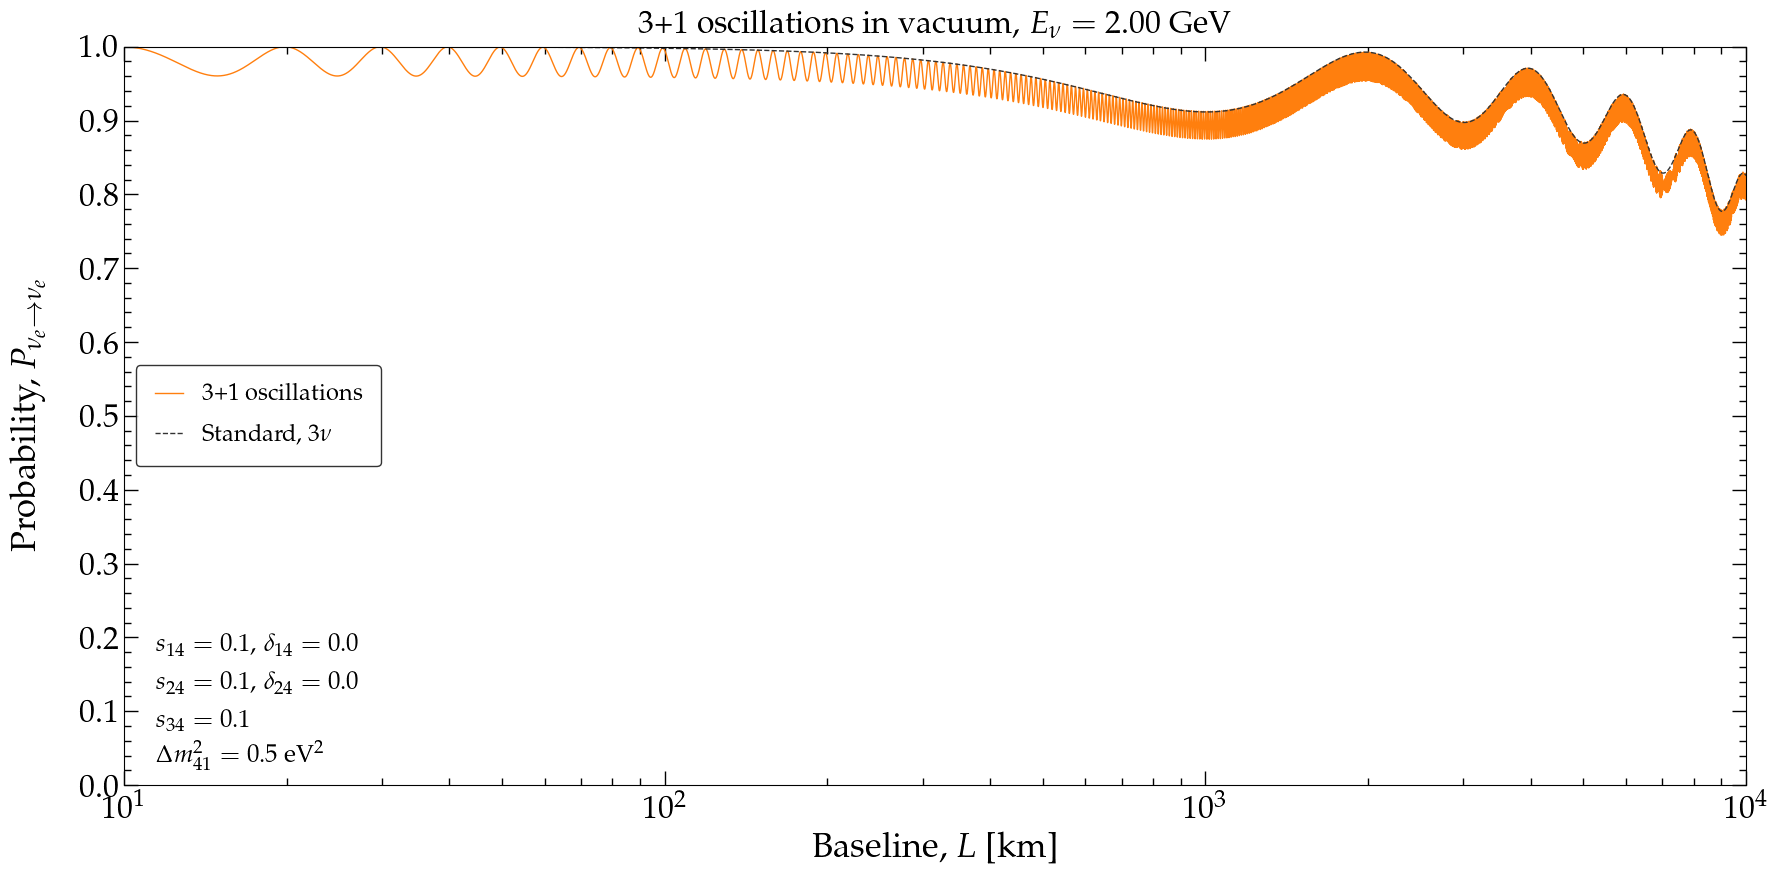

In [5]:
make_plot_prob_Nnu_3nu_vs_baseline(gd.NUE, gd.NUE, distances, prob_4nu_all, prob_3nu_all, N=1,
                                   title=r'3+1 oscillations in vacuum, $E_\nu = $~{:.2f}~GeV'.format(energy/gd.UNIT_GEV), save_plot=False)

(<Figure size 1800x900 with 1 Axes>,
 <Axes: title={'center': '3+1 oscillations in vacuum, $E_\\nu = $~2.00~GeV'}, xlabel='Baseline, $L$ [km]', ylabel='Probability,~$P_{\\nu_\\mu \\to \\nu_\\tau}$'>)

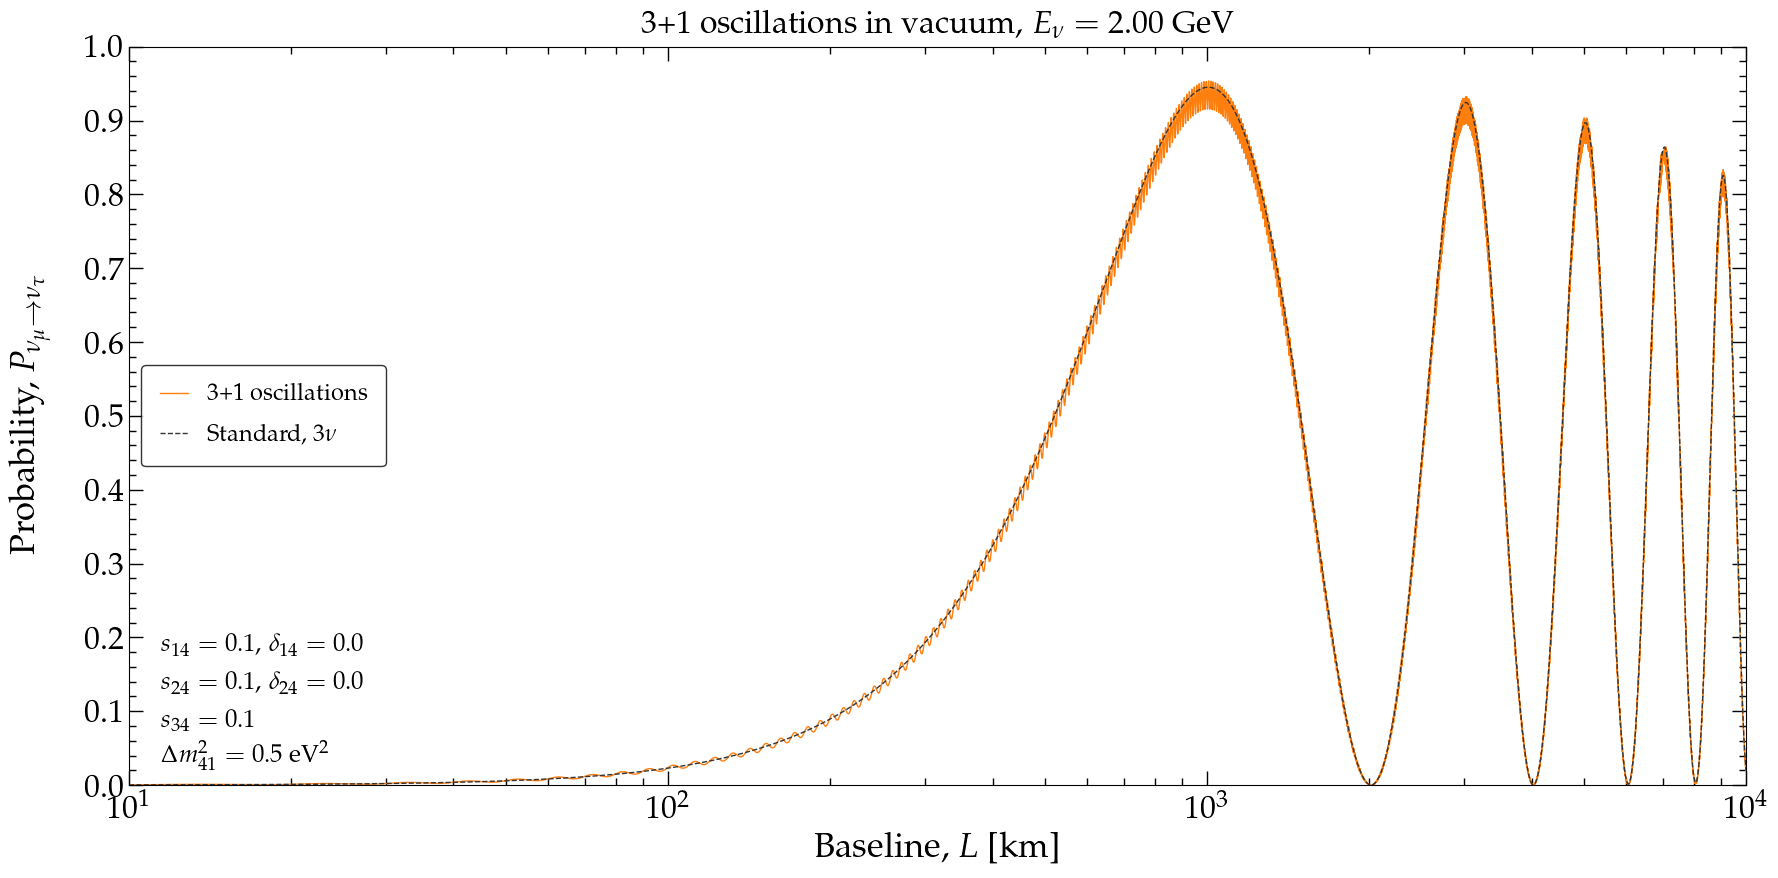

In [6]:
make_plot_prob_Nnu_3nu_vs_baseline(gd.NUMU, gd.NUTAU, distances, prob_4nu_all, prob_3nu_all, N=1, 
                                   title=r'3+1 oscillations in vacuum, $E_\nu = $~{:.2f}~GeV'.format(energy/gd.UNIT_GEV), save_plot=False)

### 1.3 Probabilities vs. energy

Generate probabilities

In [7]:
# Energies
energy_min, energy_max = 1.e0, 1.e2 # [GeV]
energy_npts = 5000
energies = np.logspace(np.log10(energy_min), np.log10(energy_max), energy_npts) # [GeV]

baseline = 5.e3 # [km]

# Standard, 3nu probabilities
H_3nu_vac_en_indep = hamiltonians.hamiltonian_3nu_vacuum_energy_independent(s12, s23, s13, dCP, D21, D31, 
                                                                               compute_matrix_multiplication=False) # Vacuum H without (1/E)
prob_3nu_all = np.array([oscprob.osc_prob(lambda l: (1/(enu*gd.UNIT_GEV))*H_3nu_vac_en_indep, 
                                          0.0, gd.CONV_KM_TO_INV_EV*baseline, 
                                          n_slabs=1, n_tpts_per_slab=10, magnus_exp_order=1) for enu in energies])

# 3+1 probabilities
H_4nu_vac_en_indep = hamiltonians.hamiltonian_4nu_vacuum_energy_independent(s12, s23, s13, dCP, s14, d14, s24, d24, s34, D21, D31, D41, 
                                                                               compute_matrix_multiplication=False) 
prob_4nu_all = np.array([oscprob.osc_prob(lambda l: (1/(enu*gd.UNIT_GEV))*H_4nu_vac_en_indep, 
                                          0.0, gd.CONV_KM_TO_INV_EV*baseline, 
                                          n_slabs=1, n_tpts_per_slab=10, magnus_exp_order=1) for enu in energies])

(<Figure size 1800x900 with 1 Axes>,
 <Axes: title={'center': '3+1 oscillations in vacuum, $L = $~5000.00~km'}, xlabel='Neutrino energy, $E_\\nu$ [GeV]', ylabel='Probability,~$P_{\\nu_e \\to \\nu_e}$'>)

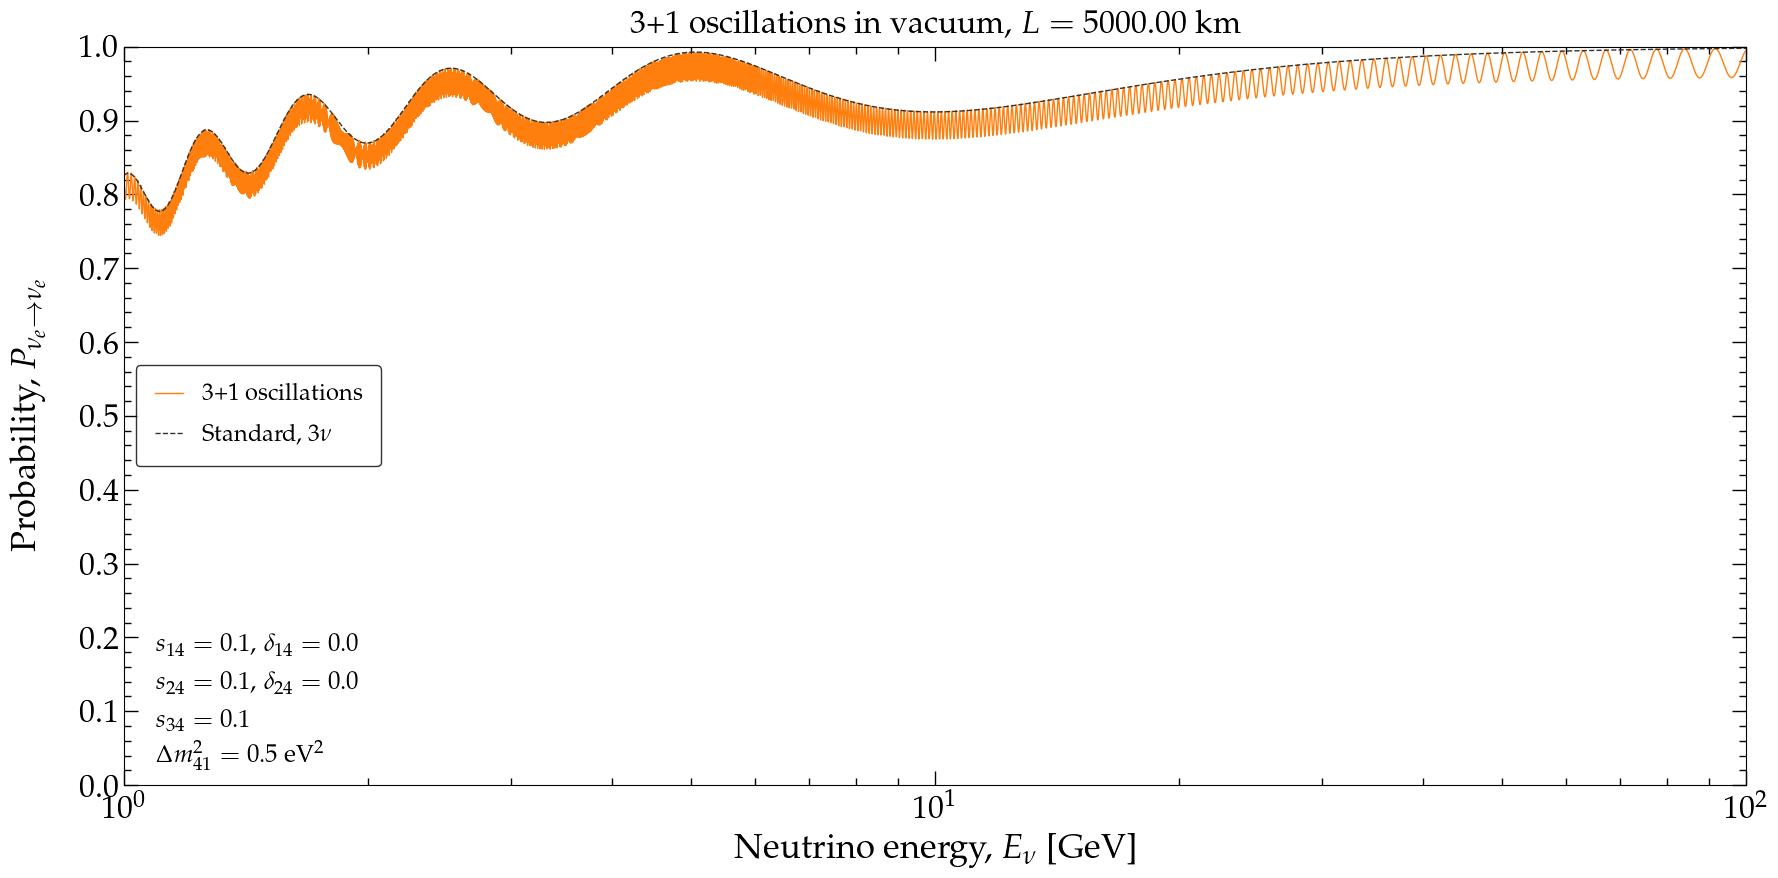

In [8]:
make_plot_prob_Nnu_3nu_vs_energy(gd.NUE, gd.NUE, energies, prob_4nu_all, prob_3nu_all, N=1,
                                 title=r'3+1 oscillations in vacuum, $L = $~{:.2f}~km'.format(baseline), save_plot=False)

(<Figure size 1800x900 with 1 Axes>,
 <Axes: title={'center': '3+1 oscillations in vacuum, $L = $~5000.00~km'}, xlabel='Neutrino energy, $E_\\nu$ [GeV]', ylabel='Probability,~$P_{\\nu_\\mu \\to \\nu_\\tau}$'>)

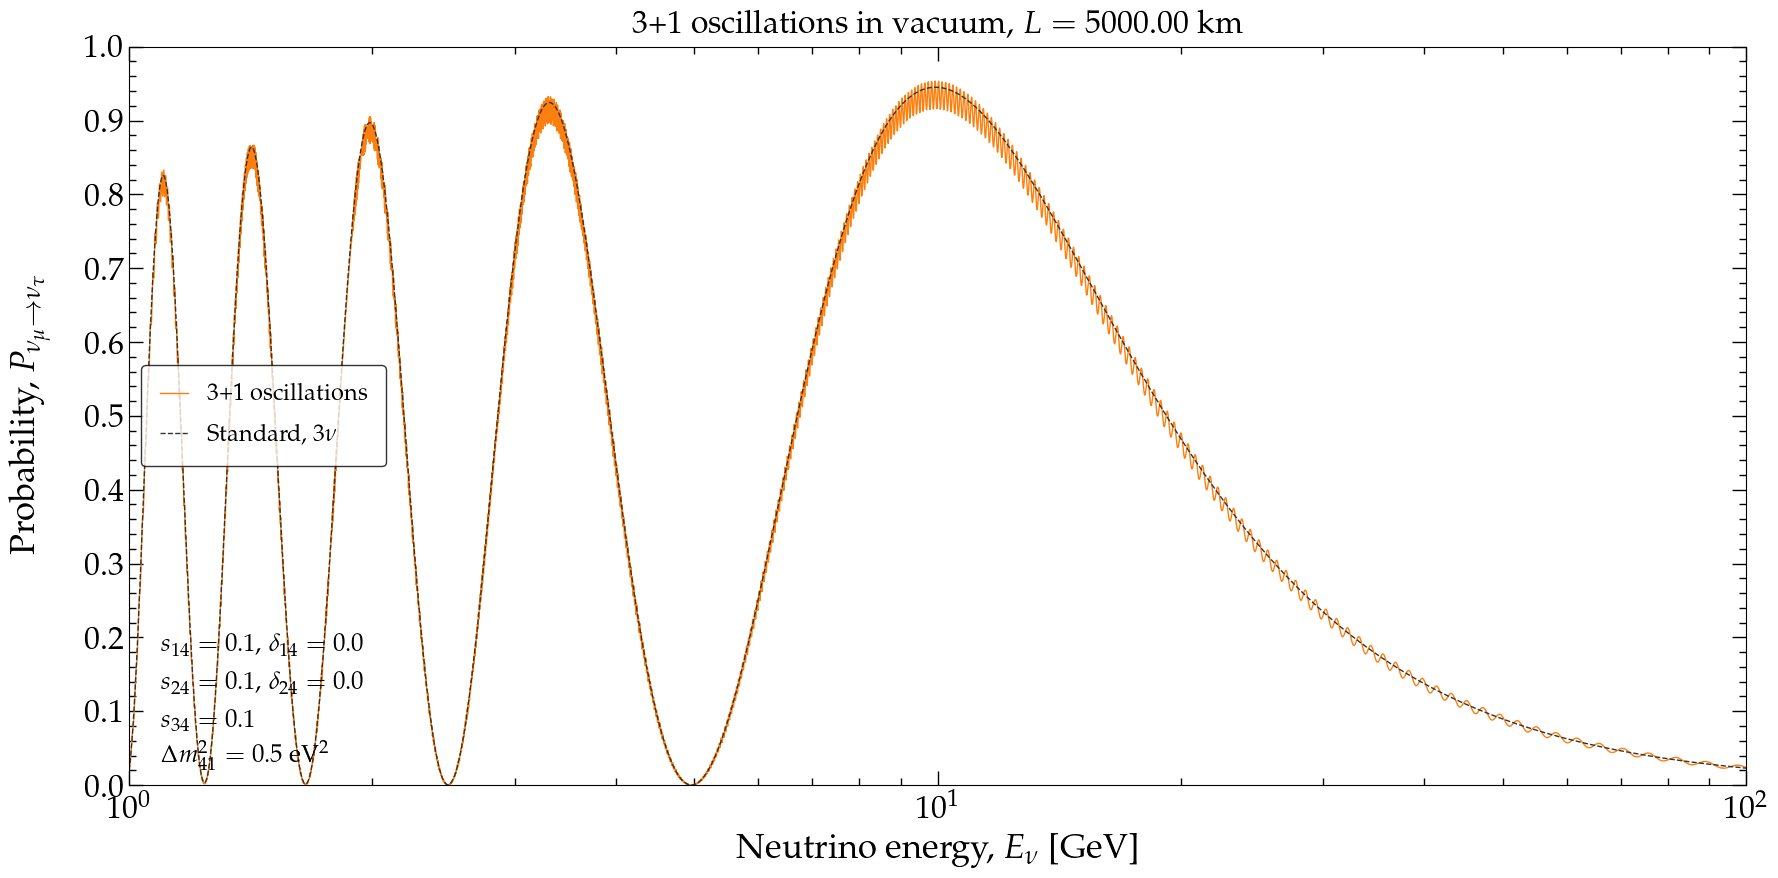

In [9]:
make_plot_prob_Nnu_3nu_vs_energy(gd.NUMU, gd.NUTAU, energies, prob_4nu_all, prob_3nu_all, N=1,
                                 title=r'3+1 oscillations in vacuum, $L = $~{:.2f}~km'.format(baseline), save_plot=False)

# 2. Probabilities in a 3+1 system ($4\nu$): in matter with constant density

### 2.1 Mixing parameters

In [10]:
# Standard mixing parameters (predefined examples from globaldefs; can change them to anything else)
s12 = gd.S12_NO_BF_NUFIT_6_0 # [adim]
s23 = gd.S23_NO_BF_NUFIT_6_0 # [adim]
s13 = gd.S13_NO_BF_NUFIT_6_0 # [adim]
dCP = gd.DCP_NO_BF_NUFIT_6_0 # [adim]
D21 = gd.D21_NO_BF_NUFIT_6_0 # [eV^2]
D31 = gd.D31_NO_BF_NUFIT_6_0 # [eV^2]

# Mixing parameters between active and sterile sectors (can change them to anything else)
s14 = 1.e-1 # [adim]
d14 = 0.0 # [adim]
s24 = 1.e-1 # [adim]
d24 = 0.0 # [adim]
s34 = 1.e-1 # [adim]
D41 = 0.5 # [eV^2]

### 2.2 Probabilities vs. distance

Generate probabilities

In [11]:
# Baselines
l_ini, l_fin = 1.e1, 1.e4 # [km]
l_npts = 10000
distances = np.logspace(np.log10(l_ini), np.log10(l_fin), l_npts) # [km]

energy = 2.0*gd.UNIT_GEV # [eV]

# Compute probability vs. baseline
# For the 3nu case, osc_prob returns a 3x3 NumPy array with the probabilities: 
# [[Pee, Pem, Pet], [Pme, Pmm, Pmt], [Pte, Ptm, Ptt]]
# For the 4nu case, osc_prob returns a 3x3 NumPy array with the probabilities:
# [[Pee, Pem, Pet, Pes], [Pme, Pmm, Pmt, Pms], [Pte, Ptm, Ptt, Pts], [Pse, Psm, Pst, Pss]]

# Matter potential
rho = 3.0 # Matter density [g cm^{-3}]
num_density_e = matter.num_density_e_func(l=0.0, density_matter_func=lambda l: rho, electron_fraction=0.5, density_matter_is_in_g_per_cm3=True) # Electron number density [eV^3]
VCC = matter.VCC_func(l=0.0, num_density_e_func=lambda l: num_density_e) # Coherent forward potential, VCC [eV]

# Standard, 3nu probabilities
H_3nu_vac = hamiltonians.hamiltonian_3nu_vacuum(energy, s12, s23, s13, dCP, D21, D31, compute_matrix_multiplication=False)
H_3nu_matt = hamiltonians.hamiltonian_3nu_matter(VCC)
H_3nu = lambda l: H_3nu_vac + H_3nu_matt
prob_3nu_all = np.array([oscprob.osc_prob(H_3nu, 0.0, l*gd.CONV_KM_TO_INV_EV, n_slabs=1, n_tpts_per_slab=2, 
                                          magnus_exp_order=1, integration_method='simpson', n_jobs=1) for l in distances])

# 3+1 probabilities
H_4nu_vac = hamiltonians.hamiltonian_4nu_vacuum(energy, s12, s23, s13, dCP, s14, d14, s24, d24, s34, D21, D31, D41, 
                                                   compute_matrix_multiplication=False)
H_4nu_matt = hamiltonians.hamiltonian_4nu_matter(VCC)
H_4nu = lambda l: H_4nu_vac + H_4nu_matt
prob_4nu_all = np.array([oscprob.osc_prob(H_4nu, 0.0, l*gd.CONV_KM_TO_INV_EV, n_slabs=1, n_tpts_per_slab=2, 
                                          magnus_exp_order=1, integration_method='simpson', n_jobs=1) for l in distances])

Plot probabilities

(<Figure size 1800x900 with 1 Axes>,
 <Axes: title={'center': '3+1 oscillations in constant-density matter (3~g~cm$^{-3}$), $E_\\nu = $~2.00~GeV'}, xlabel='Baseline, $L$ [km]', ylabel='Probability,~$P_{\\nu_e \\to \\nu_e}$'>)

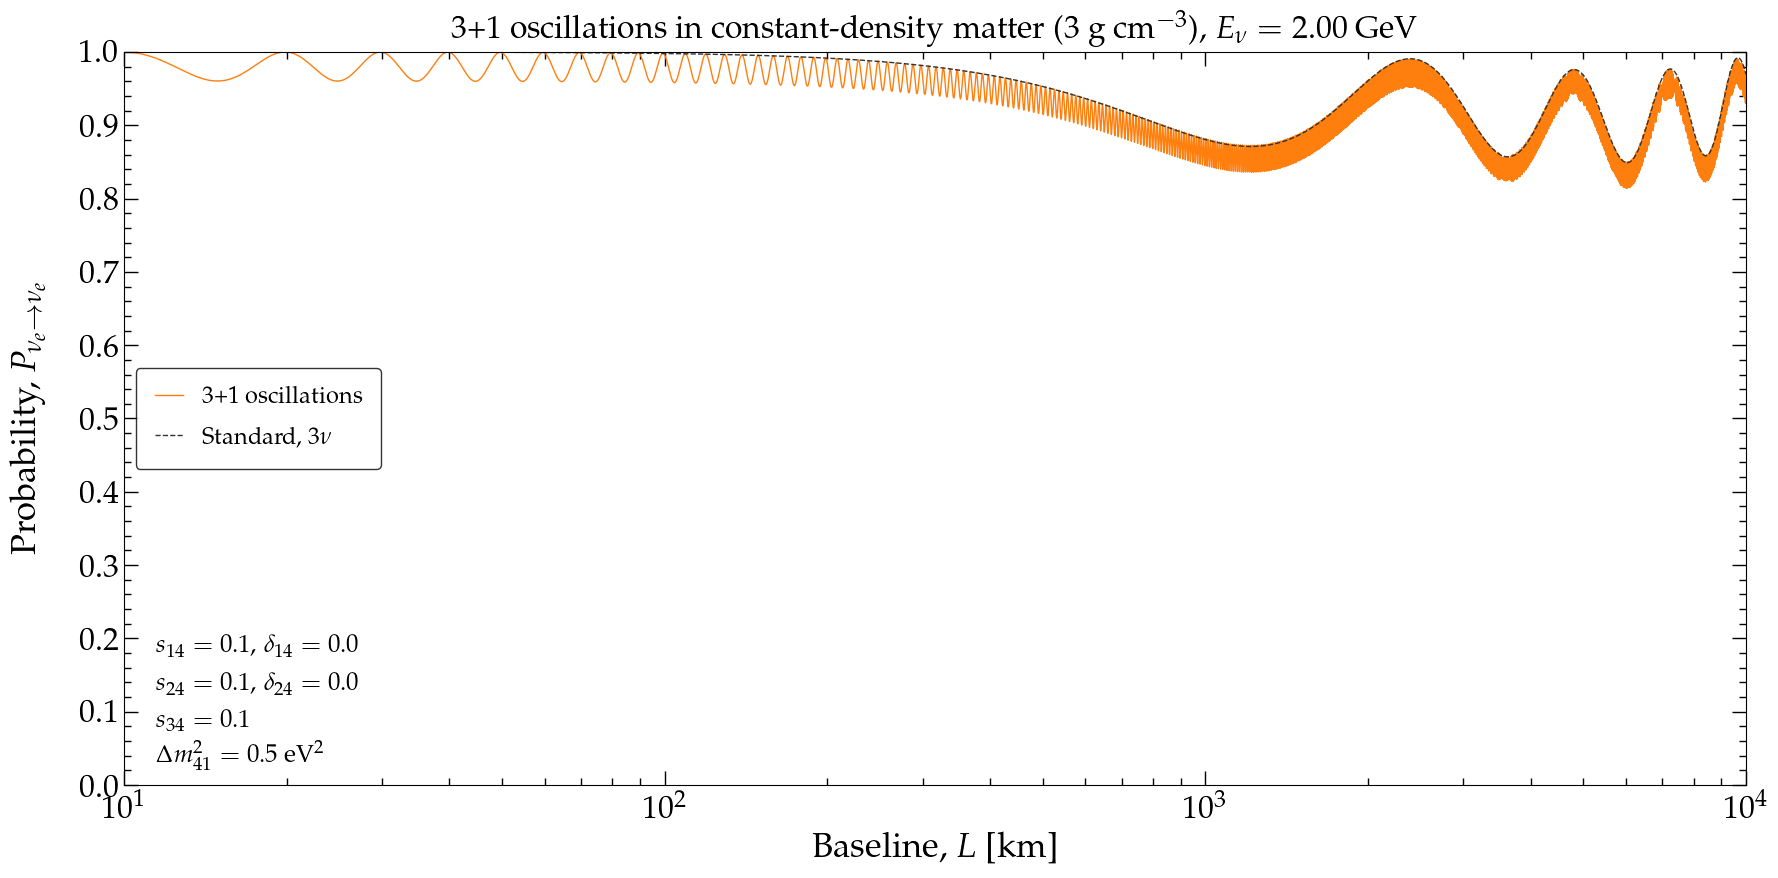

In [12]:
make_plot_prob_Nnu_3nu_vs_baseline(gd.NUE, gd.NUE, distances, prob_4nu_all, prob_3nu_all, N=1,
                                   title=r'3+1 oscillations in constant-density matter (3~g~cm$^{-3}$), ' +
                                   r'$E_\nu = $~{:.2f}~GeV'.format(energy/gd.UNIT_GEV), save_plot=False)

(<Figure size 1800x900 with 1 Axes>,
 <Axes: title={'center': '3+1 oscillations in constant-density matter (3~g~cm$^{-3}$), $E_\\nu = $~2.00~GeV'}, xlabel='Baseline, $L$ [km]', ylabel='Probability,~$P_{\\nu_\\mu \\to \\nu_\\tau}$'>)

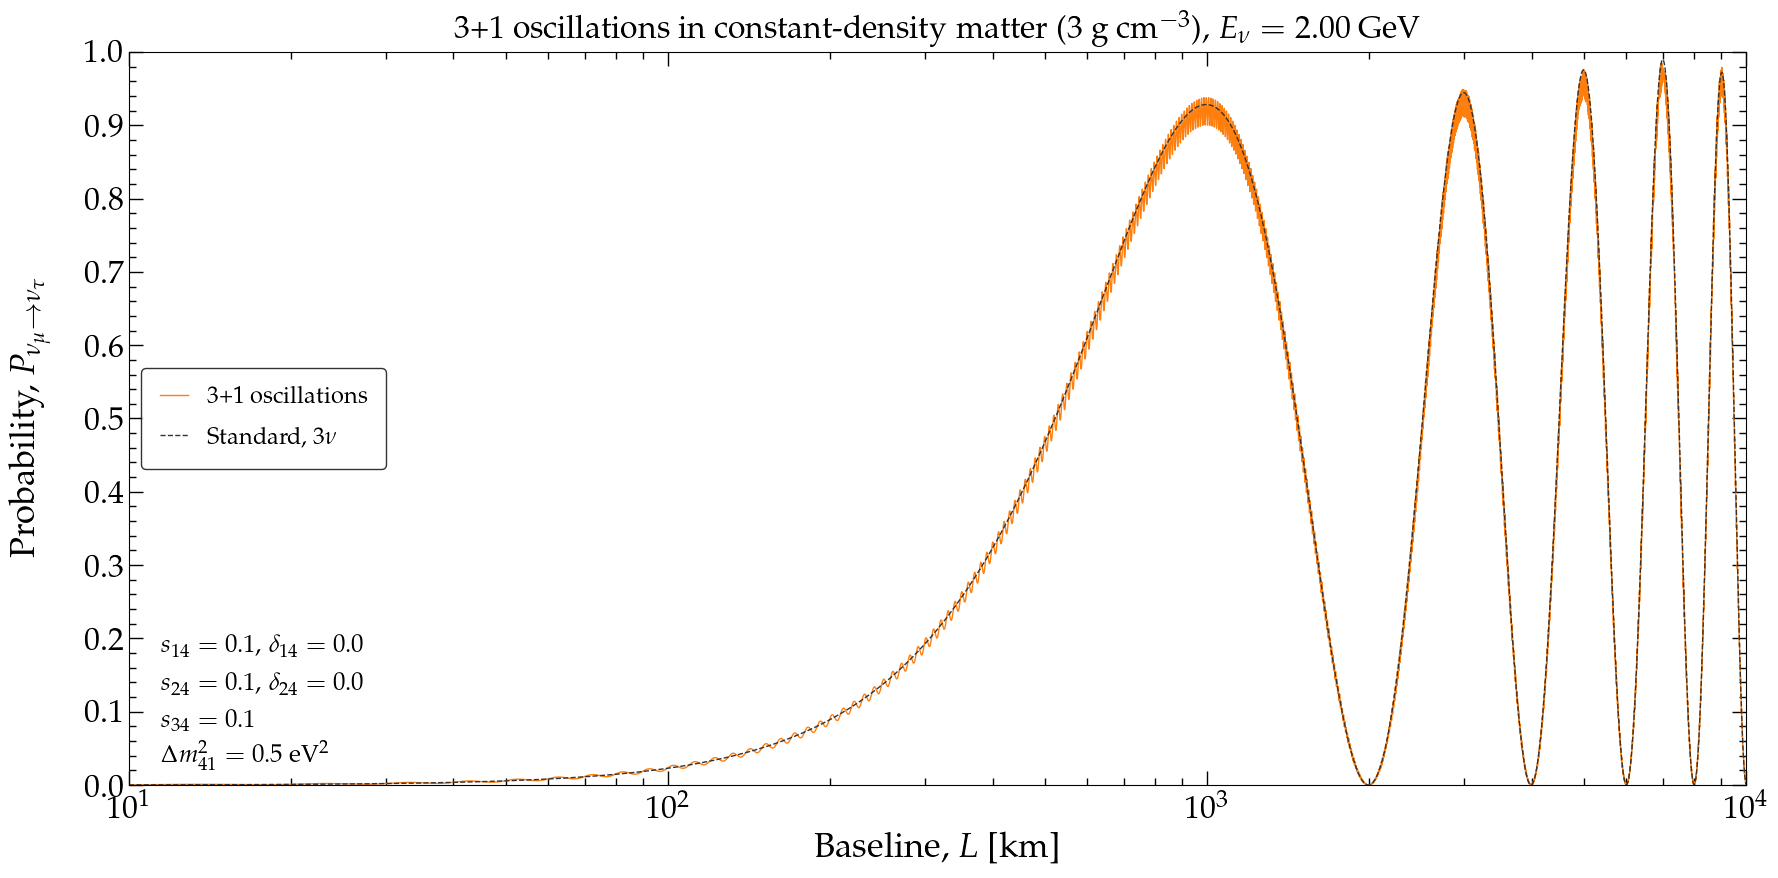

In [13]:
make_plot_prob_Nnu_3nu_vs_baseline(gd.NUMU, gd.NUTAU, distances, prob_4nu_all, prob_3nu_all, N=1,
                                   title=r'3+1 oscillations in constant-density matter (3~g~cm$^{-3}$), ' +
                                   r'$E_\nu = $~{:.2f}~GeV'.format(energy/gd.UNIT_GEV), save_plot=False)

### 2.3 Probabilities vs. energy

Generate probabilities

In [14]:
# Energies
energy_min, energy_max = 1.e-1, 1.e1 # [GeV]
energy_npts = 5000
energies = np.logspace(np.log10(energy_min), np.log10(energy_max), energy_npts) # [GeV]

baseline = 5.e3 # [km]

# Matter potential
rho = 3.0 # Matter density [g cm^{-3}]
num_density_e = matter.num_density_e_func(l=0.0, density_matter_func=lambda l: rho, electron_fraction=0.5, density_matter_is_in_g_per_cm3=True) # Electron number density [eV^3]
VCC = matter.VCC_func(l=0.0, num_density_e_func=lambda l: num_density_e) # Coherent forward potential, VCC [eV]

# Standard, 3nu probabilities
H_3nu_vac_en_indep = hamiltonians.hamiltonian_3nu_vacuum_energy_independent(s12, s23, s13, dCP, D21, D31, 
                                                                               compute_matrix_multiplication=False)
H_3nu_matt = hamiltonians.hamiltonian_3nu_matter(VCC)
def H_3nu(energy, l):
    return (1/energy)*H_3nu_vac_en_indep + H_3nu_matt
prob_3nu_all = np.array([oscprob.osc_prob(lambda l: H_3nu(enu*gd.UNIT_GEV, l), 
                                          0.0, gd.CONV_KM_TO_INV_EV*baseline, 
                                          n_slabs=1, n_tpts_per_slab=10, magnus_exp_order=1) for enu in energies])

# 3+1 probabilities
H_4nu_vac_en_indep = hamiltonians.hamiltonian_4nu_vacuum_energy_independent(s12, s23, s13, dCP, s14, d14, s24, d24, s34, D21, D31, D41, 
                                                   compute_matrix_multiplication=False)
H_4nu_matt = hamiltonians.hamiltonian_4nu_matter(VCC)
def H_4nu(energy, l):
    return (1/energy)*H_4nu_vac_en_indep + H_4nu_matt
prob_4nu_all = np.array([oscprob.osc_prob(lambda l: H_4nu(enu*gd.UNIT_GEV, l), 
                                          0.0, gd.CONV_KM_TO_INV_EV*baseline, 
                                          n_slabs=1, n_tpts_per_slab=10, magnus_exp_order=1) for enu in energies])

Plot probabilities

(<Figure size 1800x900 with 1 Axes>,
 <Axes: title={'center': '3+1 oscillations in constant-density matter (3~g~cm$^{-3}$), $L = $~5000.00~km'}, xlabel='Neutrino energy, $E_\\nu$ [GeV]', ylabel='Probability,~$P_{\\nu_e \\to \\nu_e}$'>)

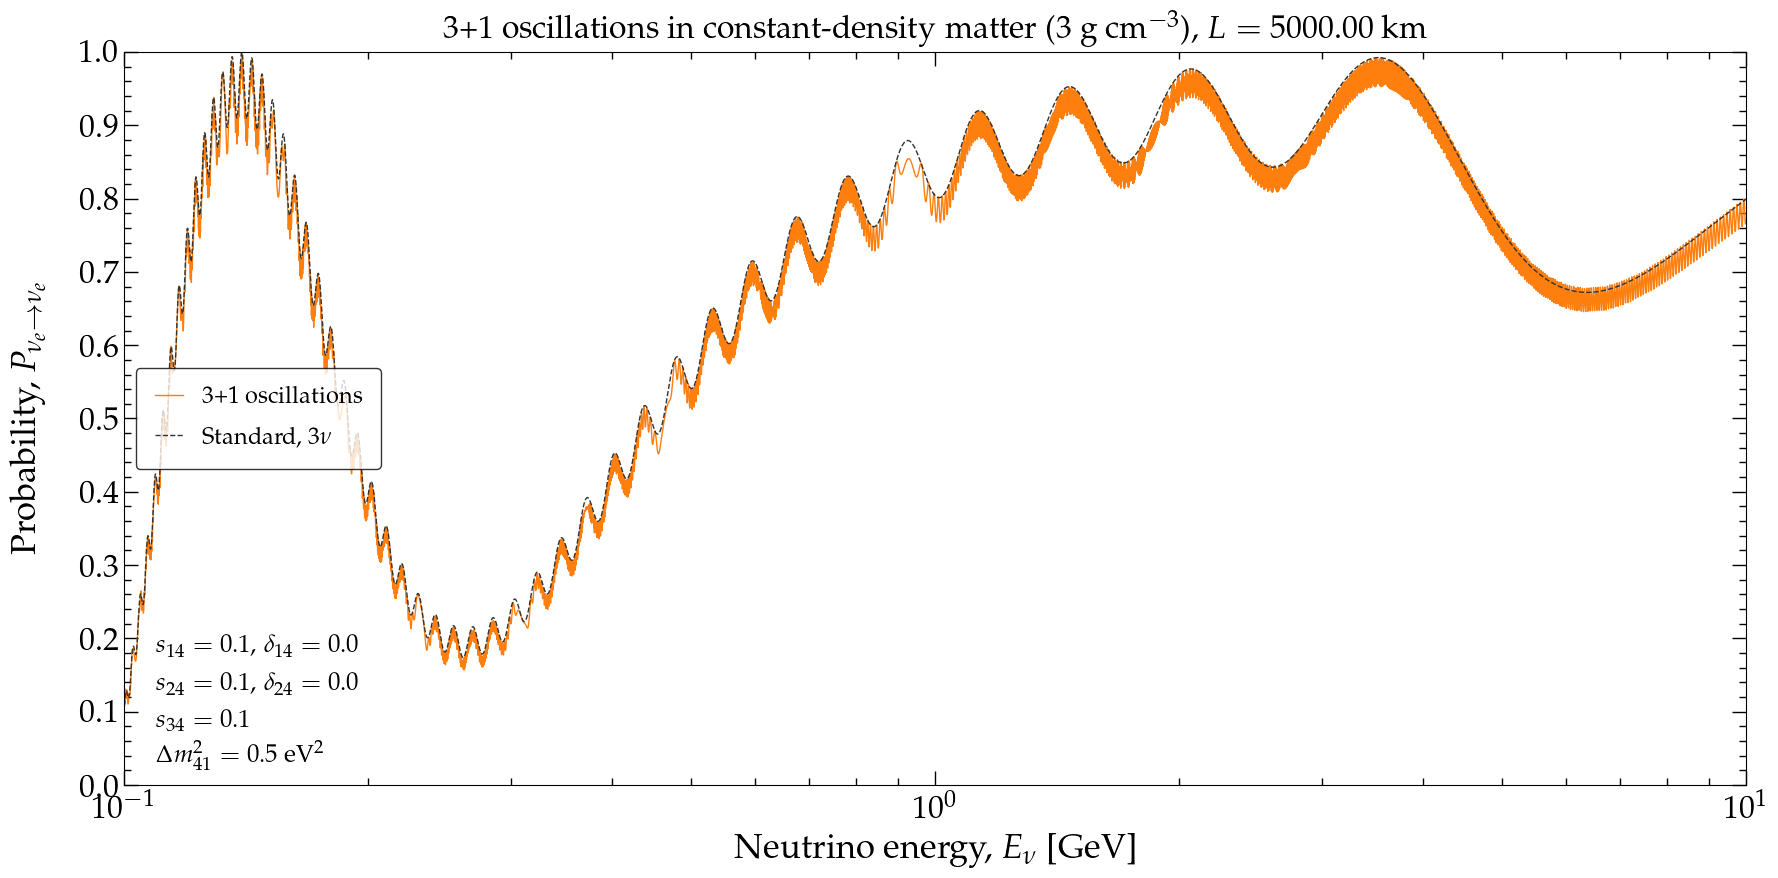

In [15]:
make_plot_prob_Nnu_3nu_vs_energy(gd.NUE, gd.NUE, energies, prob_4nu_all, prob_3nu_all, N=1,
                                 title=r'3+1 oscillations in constant-density matter (3~g~cm$^{-3}$), ' +
                                       r'$L = $~{:.2f}~km'.format(baseline), save_plot=False)

(<Figure size 1800x900 with 1 Axes>,
 <Axes: title={'center': '3+1 oscillations in constant-density matter (3~g~cm$^{-3}$), $L = $~5000.00~km'}, xlabel='Neutrino energy, $E_\\nu$ [GeV]', ylabel='Probability,~$P_{\\nu_\\mu \\to \\nu_\\tau}$'>)

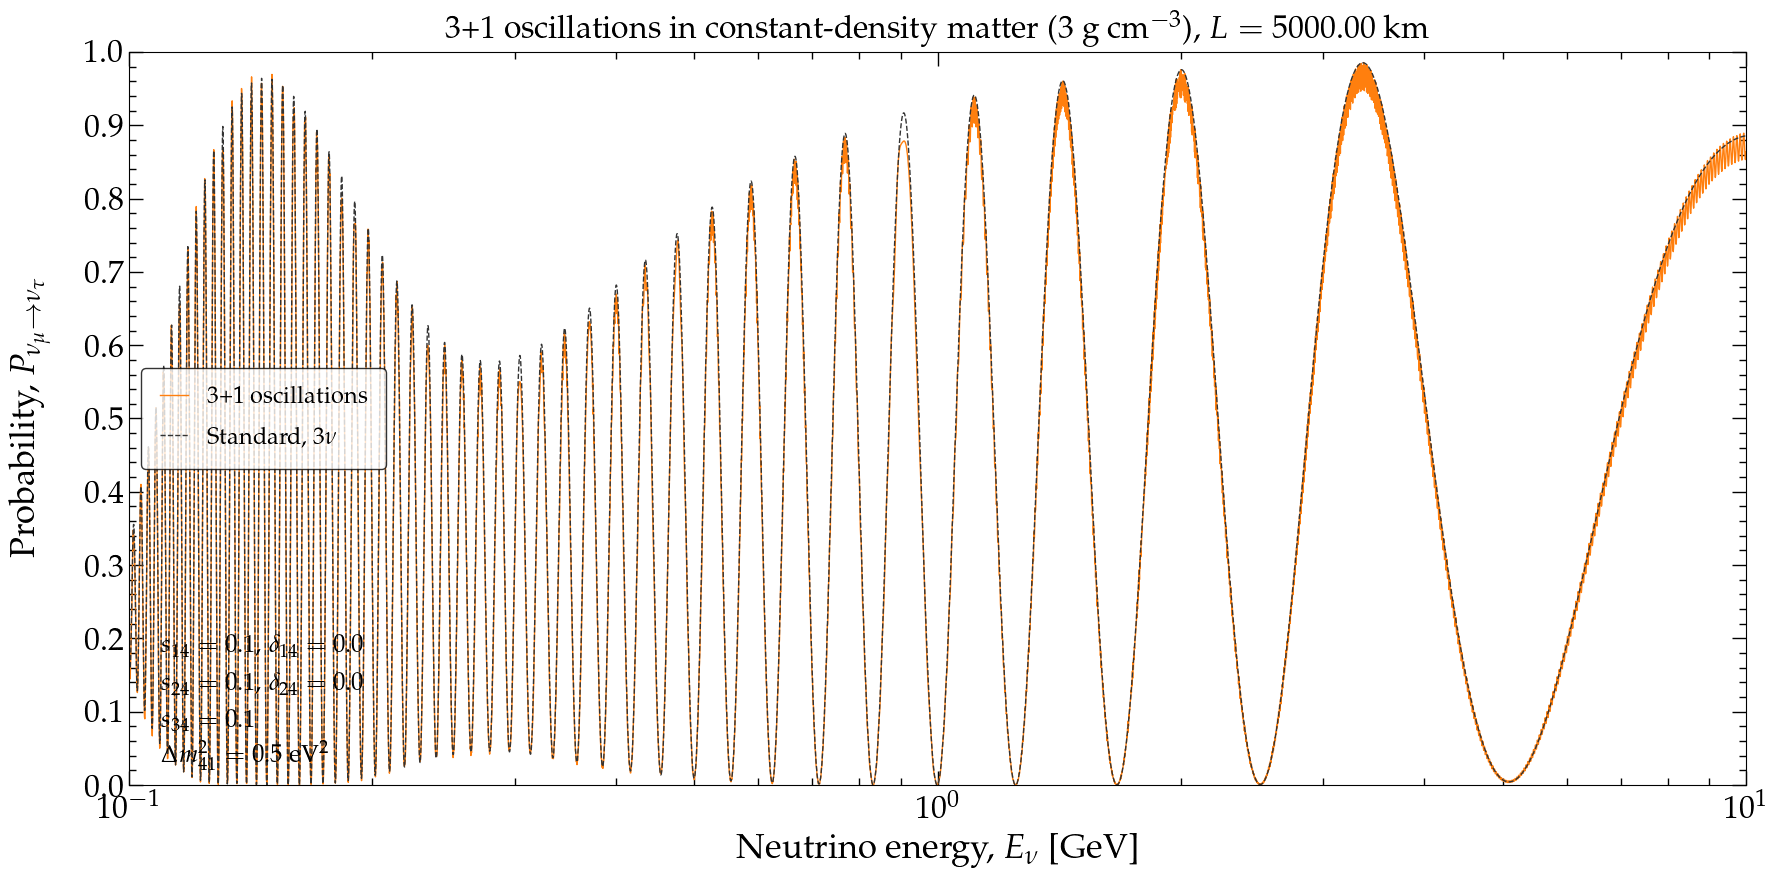

In [16]:
make_plot_prob_Nnu_3nu_vs_energy(gd.NUMU, gd.NUTAU, energies, prob_4nu_all, prob_3nu_all, N=1,
                                 title=r'3+1 oscillations in constant-density matter (3~g~cm$^{-3}$), ' +
                                       r'$L = $~{:.2f}~km'.format(baseline), save_plot=False)

# 3. Probabilities in a 3+1 system ($4\nu$): long-baseline inside Earth (PREM)

For more details about computing and plotting probabilities in long-baseline experimental setups, see notebook `04_magnus_long_baseline.ipynb`.

### 3.1 Mixing parameters

In [17]:
# Standard mixing parameters (predefined examples from globaldefs; can change them to anything else)
s12 = gd.S12_NO_BF_NUFIT_6_0 # [adim]
s23 = gd.S23_NO_BF_NUFIT_6_0 # [adim]
s13 = gd.S13_NO_BF_NUFIT_6_0 # [adim]
dCP = gd.DCP_NO_BF_NUFIT_6_0 # [adim]
D21 = gd.D21_NO_BF_NUFIT_6_0 # [eV^2]
D31 = gd.D31_NO_BF_NUFIT_6_0 # [eV^2]

# Electron number density inside Earth, using the PREM density model
def num_density_e_func_prem(r): 
    return matter.num_density_e_func(r, earth.density_matter_func_prem, electron_fraction=0.5, density_matter_is_in_g_per_cm3=True) # [eV^{-3}]

# Coherent forward potential inside Earth, using the PREM density model
def VCC_func_prem(r):
    return matter.VCC_func(r, num_density_e_func_prem) # [eV]

# Cosines of zenith angles of Fermilab measured from the detector locations (we would get the same result if we seapped them, since we
# consider that Earth is radially symmetric)
detectors = ['SNOLAB', 'Homestake', 'CERN', "South Pole"]
costhz_arr = [earth.costhz_between_points_on_surface(earth.loc_coords_dms[det.lower().replace(" ", "_")]['lat'], 
                                                     earth.loc_coords_dms[det.lower().replace(" ", "_")]['lon'],
                                                     earth.loc_coords_dms['fermilab']['lat'], 
                                                     earth.loc_coords_dms['fermilab']['lon']) 
             for det in detectors]

# Maximum baselines inside the Earth
l_max_arr = [earth.distance_traveled_inside_earth(costhz) for costhz in costhz_arr] # [km]

### 3.2 Probabilities vs. energy

Define the Hamiltonians

In [18]:
# Mixing parameters between active and sterile sectors (can change them to anything else)
s14 = 2.e-1 # [adim]
d14 = 0.0 # [adim]
s24 = 1.e-1 # [adim]
d24 = 0.0 # [adim]
s34 = 1.e-1 # [adim]
D41 = 0.5 # [eV^2]

# Vacuum Hamiltonian without the 1/E prefactor 
H_3nu_vac_en_indep = hamiltonians.hamiltonian_3nu_vacuum_energy_independent(s12, s23, s13, dCP, D21, D31, 
                                                                               compute_matrix_multiplication=False)
H_4nu_vac_en_indep = hamiltonians.hamiltonian_4nu_vacuum_energy_independent(s12, s23, s13, dCP, s14, d14, s24, d24, s34, D21, D31, D41, 
                                                                               compute_matrix_multiplication=False)

# Hamiltonian including matter effects inside Earth using the PREM density model
def H_3nu_prem(costhz, l, energy):
    # Given a direction (costhz) and a depth (l), compute the radial distance from the center of the Earth (r)
    r = earth.earth_radial_distance_from_depth(costhz, l/gd.CONV_KM_TO_INV_EV) # [km]
    return (1/energy)*H_3nu_vac_en_indep + hamiltonians.hamiltonian_3nu_matter(VCC_func_prem(r))
    
def H_4nu_prem(costhz, l, energy):
    r = earth.earth_radial_distance_from_depth(costhz, l/gd.CONV_KM_TO_INV_EV) # [km]
    return (1/energy)*H_4nu_vac_en_indep + hamiltonians.hamiltonian_4nu_matter(VCC_func_prem(r))

Generate the probabilities

In [19]:
# This scan is the most expensive cell in the notebook: four trajectories, two
# flavour counts, and a genuine PREM profile sampled inside every slab.
#
# The grid is deliberately coarse. With D41 = 0.5 eV^2 the sterile oscillation
# accumulates ~1e9 radians over an Earth-crossing baseline at these energies, so
# the curve is aliased at *any* practical number of points -- a denser grid draws
# a different alias, not a better-resolved oscillation. What survives sampling is
# the envelope and the average, and 200 points show those as well as 3000 did, at
# a fifteenth of the cost.
nu_i, nu_f = gd.NUE, gd.NUE # Initial and final flavors; can also choose NUMU or NUTAU

# Energies
energy_min, energy_max = 1.e1, 1.e2 # [MeV]
energy_npts = 200   # see the note below on why a dense grid buys nothing here
energies = np.logspace(np.log10(energy_min), np.log10(energy_max), energy_npts) # [MeV]

# Generate probabilities for the different directions
prob_3nu_arr, prob_4nu_arr = [], []
for i in range(len(costhz_arr)):
    print("detector = " + detectors[i])
    prob_3nu = np.array([oscprob.osc_prob(lambda l: H_3nu_prem(costhz_arr[i], l, enu*gd.UNIT_MEV), 
                                          0, l_max_arr[i]*gd.CONV_KM_TO_INV_EV, 
                                          n_slabs=100, n_tpts_per_slab=20, magnus_exp_order=3, n_jobs=10)[nu_i][nu_f] for enu in energies]) 
    prob_4nu = np.array([oscprob.osc_prob(lambda l: H_4nu_prem(costhz_arr[i], l, enu*gd.UNIT_MEV), 
                                          0, l_max_arr[i]*gd.CONV_KM_TO_INV_EV, 
                                          n_slabs=100, n_tpts_per_slab=20, magnus_exp_order=3, n_jobs=10)[nu_i][nu_f] for enu in energies]) 
    prob_3nu_arr.append(prob_3nu)
    prob_4nu_arr.append(prob_4nu)

detector = SNOLAB


/home/mbustamante/Research/magnus/src/magnus/magnus.py:1385: MagnusConvergenceWarning: at least one time slab is too wide for guaranteed convergence of the Magnus series (||Omega||_2 >= pi, marginally over). This is a statement about the slab width, not about the answer: it reports that a sufficient condition for convergence was not met somewhere, and the error may be anywhere from negligible to large. To act on it, use more (narrower) slabs -- request a smaller rtol/atol, or raise n_slabs; raising magnus_exp_order will not help in this regime. If the profile has a density jump or a kink, pass t_breakpoints there as well: a slab straddling one is not fixed by any number of slabs. Do NOT assume the adaptive refinement has already taken care of it -- measured on a sawtooth density with rtol=atol=1e-3 explicitly requested, the refinement ran and the answer was still 7.5e-03, seven times outside the tolerance asked for. Shown once per session.
  return evolution_operators_from_samples(At, 

/home/mbustamante/Research/magnus/src/magnus/magnus.py:1385: MagnusConvergenceWarning: at least one time slab is too wide for guaranteed convergence of the Magnus series (||Omega||_2 >= pi, over by up to a factor of ten). This is a statement about the slab width, not about the answer: it reports that a sufficient condition for convergence was not met somewhere, and the error may be anywhere from negligible to large. To act on it, use more (narrower) slabs -- request a smaller rtol/atol, or raise n_slabs; raising magnus_exp_order will not help in this regime. If the profile has a density jump or a kink, pass t_breakpoints there as well: a slab straddling one is not fixed by any number of slabs. Do NOT assume the adaptive refinement has already taken care of it -- measured on a sawtooth density with rtol=atol=1e-3 explicitly requested, the refinement ran and the answer was still 7.5e-03, seven times outside the tolerance asked for. Shown once per session.
  return evolution_operators_fro

detector = Homestake


/tmp/ipykernel_1369268/2549039937.py:24: ToleranceNotAchievedWarning: osc_prob: requested tolerance not achieved (max_n_slabs reached), the last two refinement levels still differing by a few times the tolerance, so convergence could not be verified by successive refinement and the returned probabilities may be inaccurate. Raise max_n_slabs. This can happen for very large accumulated phases, e.g., low-energy neutrinos over very long baselines, or eV-scale sterile splittings over Earth-crossing baselines. If the profile has a density jump or a kink, pass t_breakpoints there as well -- a slab straddling one is never fixed by more slabs. Shown once per session.
  prob_4nu = np.array([oscprob.osc_prob(lambda l: H_4nu_prem(costhz_arr[i], l, enu*gd.UNIT_MEV),


detector = CERN


/home/mbustamante/Research/magnus/src/magnus/magnus.py:1385: MagnusConvergenceWarning: at least one time slab is too wide for guaranteed convergence of the Magnus series (||Omega||_2 >= pi, over by more than a factor of ten). This is a statement about the slab width, not about the answer: it reports that a sufficient condition for convergence was not met somewhere, and the error may be anywhere from negligible to large. To act on it, use more (narrower) slabs -- request a smaller rtol/atol, or raise n_slabs; raising magnus_exp_order will not help in this regime. If the profile has a density jump or a kink, pass t_breakpoints there as well: a slab straddling one is not fixed by any number of slabs. Do NOT assume the adaptive refinement has already taken care of it -- measured on a sawtooth density with rtol=atol=1e-3 explicitly requested, the refinement ran and the answer was still 7.5e-03, seven times outside the tolerance asked for. Shown once per session.
  return evolution_operators

detector = South Pole


Plot the probabilities

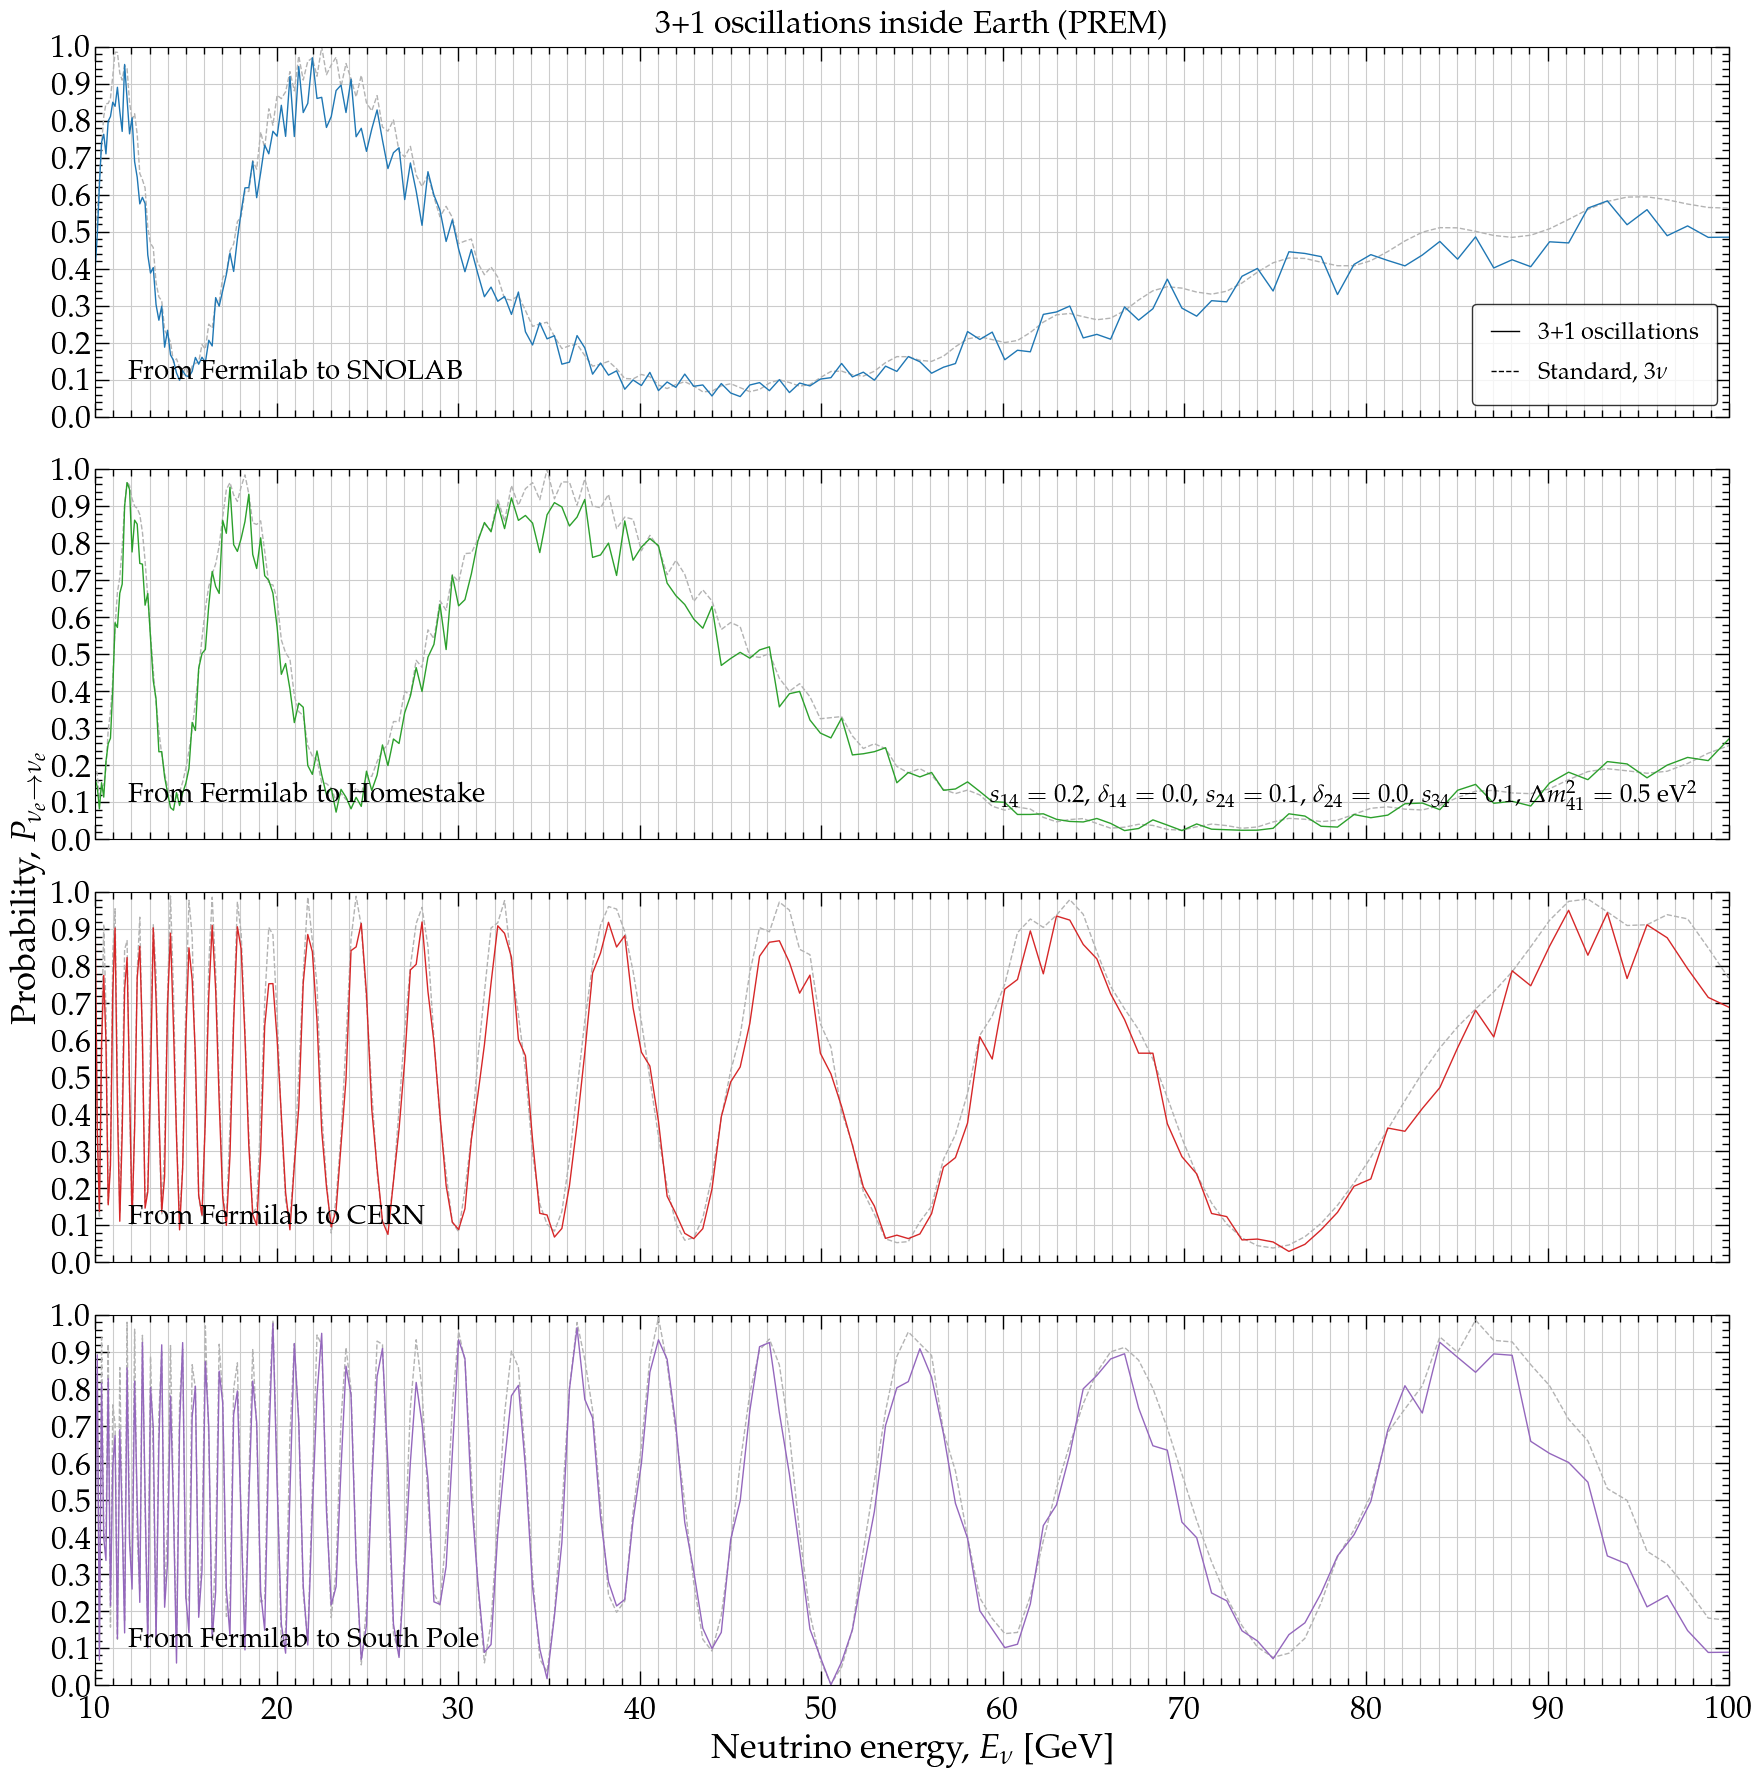

In [20]:
# One panel per trajectory, sharing an abscissa: the comparison the reader makes
# is between panels, so every panel has to carry identical limits, scales and
# tick spacings. plot_curves_stacked enforces that rather than leaving it to
# four hand-repeated formatting loops.
#
# The legend describes line *style*, not colour -- the 3+1 curve is a different
# colour in every panel -- so it is built from legend_proxies. That replaces the
# older trick of plotting dummy points at (-1, -1), outside the axis limits,
# purely to manufacture legend handles.
lc = ['C0', 'C2', 'C3', 'C4']
panels = [[dict(y=prob_3nu_arr[i], color='0.7', ls='--'),
           dict(y=prob_4nu_arr[i], color=lc[i], ls='-')]
          for i in range(len(costhz_arr))]

fig, ax = plotting.plot_curves_stacked(
    energies, panels,
    xlabel=r'Neutrino energy, $E_\nu$~[GeV]',
    ylabel=r'Probability,~'+plotting.prob_label(nu_i, nu_f),
    title=r'3+1 oscillations inside Earth (PREM)',
    xlim=(energy_min, energy_max), ylim=(0, 1),
    xmajor=10, xminor=1, ymajor=0.10, yminor=0.02,
    panel_labels=[r'From Fermilab to '+d for d in detectors],
    legend_proxies=[dict(label=r'3+1 oscillations', color='k', ls='-', lw=1),
                    dict(label=r'Standard, $3\nu$', color='k', ls='--', lw=1)],
    legend_loc='lower right',
    annotations=[dict(
        text=r'$s_{14} = $ '+str(s14)+r', $\delta_{14} = $ '+str(d14)
             + r', $s_{24} = $ '+str(s24)+r', $\delta_{24} = $ '+str(d24)
             + r', $s_{34} = $ '+str(s34)+r', $\Delta m_{41}^2 =$ '+str(D41)+r' eV$^2$',
        xy=(0.98, 0.10), panel=1, ha='right', fontsize=18)],
    grid=True, grid_kw=dict(axis='x'),
)

# The original draws two different grids -- minor on x, major only on y -- which
# is one call more than `grid_kw` expresses. Every function here returns
# (fig, ax) so that a packaged figure is a starting point rather than a dead
# end; this is that escape hatch doing its job.
for axx in ax:
    axx.grid(visible=True, c='0.8', which='major', axis='y')

### 3.3 Probabilities vs. active-sterile mixing parameter

Let's pick a baseline from Fermilab to Homestake (i.e., DUNE), which is about 1300 km, and see how the probability changes with the value of one of the active-sterile mixing parameters.  This is part of the analysis chain used to place bounds on the values of sterile neutrino mixing parameters.

Generate the probabilities

In [21]:
nu_i, nu_f = gd.NUMU, gd.NUE # Initial and final flavors; can also choose NUMU or NUTAU

# Energies
energy = 2.0*gd.UNIT_GEV # [eV]

# Zenith angle corresponding to Fermilab-Homestake (already computed above)
costhz = costhz_arr[1]

# Chord length Fermilab-Homestake
l_max = l_max_arr[1] # [km]

# Fixed mixing parameters between active and sterile sectors (can change them to anything else)
s14 = 1.e-1 # [adim]
d14 = 0.0 # [adim]
# s24 = 1.e-1 # [adim]
d24 = 0.0 # [adim]
s34 = 1.e-1 # [adim]
D41 = 1.e3 # [eV^2]

# Active-sterile mixing parameters that we vary
s24_npts = 100
s24_arr = np.linspace(0.0, 1.0, s24_npts) # [adim]
D41_arr = [1.e-2, 1.e-1, 1.e0, 1.e1] # [eV^2]
D41_label = [r'$\Delta m_{41}^2 = 0.01$~eV$^2$', r'$\Delta m_{41}^2 = 0.1$~eV$^2$', r'$\Delta m_{41}^2 = 1$~eV$^2$', 
             r'$\Delta m_{41}^2 = 10$~eV$^2$']

# Hamiltonian including matter effects inside Earth using the PREM density model
def H_3nu_prem(costhz, l, energy):
    # Given a direction (costhz) and a depth (l), compute the radial distance from the center of the Earth (r)
    r = earth.earth_radial_distance_from_depth(costhz, l/gd.CONV_KM_TO_INV_EV) # [km]
    return hamiltonians.hamiltonian_3nu_vacuum(energy, s12, s23, s13, dCP, D21, D31) \
            + hamiltonians.hamiltonian_3nu_matter(VCC_func_prem(r))
    
def H_4nu_prem(costhz, l, energy, s14, d14, s24, d24, s34, D21, D31, D41):
    r = earth.earth_radial_distance_from_depth(costhz, l/gd.CONV_KM_TO_INV_EV) # [km]
    return hamiltonians.hamiltonian_4nu_vacuum(energy, s12, s23, s13, dCP, s14, d14, s24, d24, s34, D21, D31, D41) \
            + hamiltonians.hamiltonian_4nu_matter(VCC_func_prem(r))

Generate the probabilities

In [22]:
prob_3nu = oscprob.osc_prob(lambda l: H_3nu_prem(costhz, l, energy), 
                                      0, l_max*gd.CONV_KM_TO_INV_EV, 
                                      n_slabs=100, n_tpts_per_slab=20, magnus_exp_order=3, n_jobs=10)[nu_i][nu_f]

prob_4nu = np.array([[oscprob.osc_prob(lambda l: H_4nu_prem(costhz, l, energy, s14, d14, s24, d24, s34, D21, D31, D41), 
                                      0, l_max*gd.CONV_KM_TO_INV_EV, 
                                      n_slabs=100, n_tpts_per_slab=20, magnus_exp_order=3, n_jobs=10)[nu_i][nu_f] for s24 in s24_arr]
                     for D41 in D41_arr])

/home/mbustamante/Research/magnus/src/magnus/magnus.py:1385: MagnusConvergenceWarning: at least one time slab is too wide for guaranteed convergence of the Magnus series (||Omega||_2 >= pi, over by up to a factor of ten). This is a statement about the slab width, not about the answer: it reports that a sufficient condition for convergence was not met somewhere, and the error may be anywhere from negligible to large. To act on it, use more (narrower) slabs -- request a smaller rtol/atol, or raise n_slabs; raising magnus_exp_order will not help in this regime. If the profile has a density jump or a kink, pass t_breakpoints there as well: a slab straddling one is not fixed by any number of slabs. Do NOT assume the adaptive refinement has already taken care of it -- measured on a sawtooth density with rtol=atol=1e-3 explicitly requested, the refinement ran and the answer was still 7.5e-03, seven times outside the tolerance asked for. Shown once per session.
  return evolution_operators_fro

Plot the probabilities

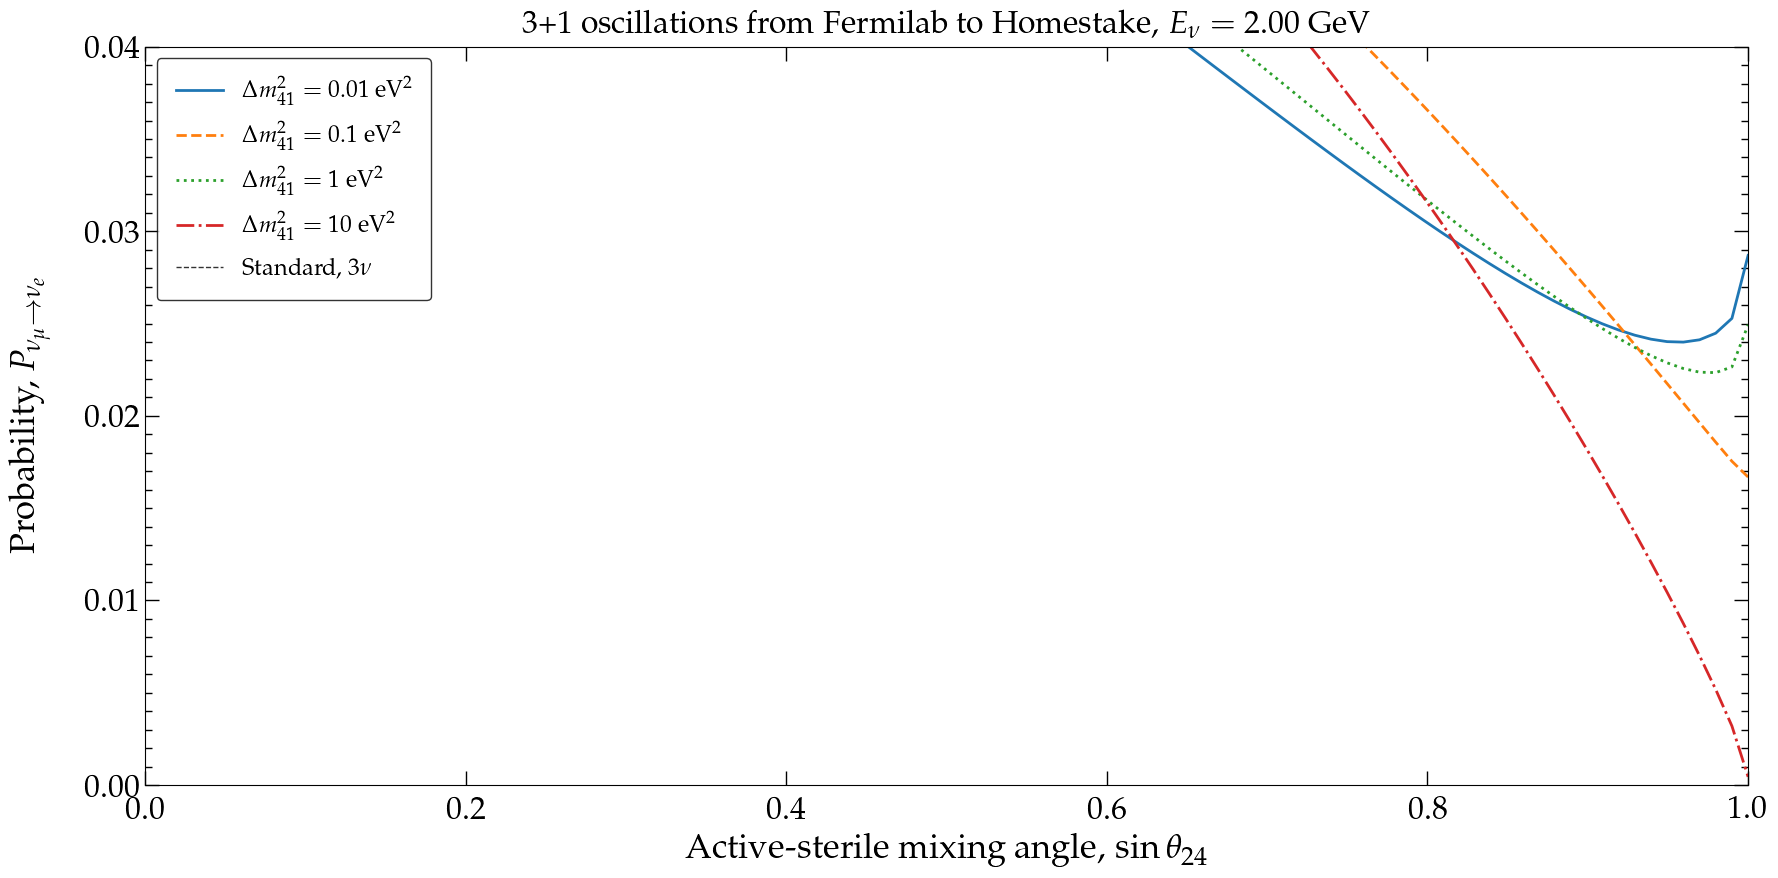

In [23]:
# A plain set of curves against a swept variable, which is what plot_curves is
# for. (The hand-built version carried a 1x1 gridspec_kw, which did nothing.)
ls = ['-', '--', ':', '-.']
fig, ax = plotting.plot_curves(
    s24_arr,
    [dict(y=prob_4nu[i], lw=2, color=f'C{i}', ls=ls[i], label=D41_label[i])
     for i in range(len(D41_arr))]
    + [dict(y=np.full_like(s24_arr, prob_3nu), lw=1, color='0.2', ls='--',
            label=r'Standard, $3\nu$')],
    xlabel=r'Active-sterile mixing angle, $\sin \theta_{24}$',
    ylabel=r'Probability,~'+plotting.prob_label(nu_i, nu_f),
    title=r'3+1 oscillations from Fermilab to Homestake, '
          r'$E_\nu = $~{:.2f}~GeV'.format(energy/gd.UNIT_GEV),
    xlim=(s24_arr[0], s24_arr[-1]), ylim=(0, 0.04),
    ymajor=0.01, yminor=0.001,
    legend_loc='upper left', legend_kw=dict(handlelength=2),
    title_fontsize=23,
)

# 4. Probabilities in a 3+2 system ($5\nu$)

Neutrino oscillations in a 3+2 system proceed similarly as in a 3+1 system, but driven instead by a $5 \times 5$ mixing matrix (see Eqs. (3) and (5) in arXiv:1105.3911),
\begin{equation}
U_{5\nu} = \tilde{R}_{35} ~ R_{34} ~ R_{25} ~ \tilde{R}_{24} ~ R_{23} ~ \tilde{R}_{15} ~ \tilde{R}_{14} ~ \tilde{R}_{13} ~ R_{12} \;,
\end{equation}
where the rotation matrices $R_{ij}$ and $\tilde{R}_{ij}$ are defined as above for the 3+1 system and, again, we have not written the matrix containing Majorana phases. In addition, there are now two new mass-squared difference, $\Delta m_{41}^2$ and $\Delta m_{51}^2$.

Thus, there are twelve new mixing parameters that we need to supply to Mag$\nu$s: $s_{14}$ (`s14`), $\delta_{14}$ (`d14`), $s_{15}$ (`s15`), $\delta_{15}$ (`d15`), $s_{24}$ (`s24`), $\delta_{24}$ (`d24`), $s_{25}$ (`s25`), $s_{34}$ (`s34`), $s_{35}$ (`s35`), $\delta_{35}$ (`d35`), $\Delta m_{41}^2$ (`D41`), and $\Delta m_{51}^2$ (`D51`).  These parameters are passed *in addition* to the standard mixing parameters in three-neutrino oscillations.

Oscillation probabilities in the 3+2 system are computed just as we did in the 3+1 system, but the Hamiltonian is now a $5 \times 5$ matrix, and the `osc_prob` function now returns a $5 \times 5$ probability matrix.  

Below, we show an examply only for oscillations in vacuum.  It is straightforward to produce all the other cases we showed for 3+1 above also for 3+2.

### 4.1 Mixing parameters

In [24]:
# Standard mixing parameters (predefined examples from globaldefs; can change them to anything else)
s12 = gd.S12_NO_BF_NUFIT_6_0 # [adim]
s23 = gd.S23_NO_BF_NUFIT_6_0 # [adim]
s13 = gd.S13_NO_BF_NUFIT_6_0 # [adim]
dCP = gd.DCP_NO_BF_NUFIT_6_0 # [adim]
D21 = gd.D21_NO_BF_NUFIT_6_0 # [eV^2]
D31 = gd.D31_NO_BF_NUFIT_6_0 # [eV^2]

# Mixing parameters between active and sterile sectors (can change them to anything else)
s14 = 1.e-1 # [adim]
d14 = 0.0 # [adim]
s15 = 1.e-1 # [adim]
d15 = 0.0 # [adim]
s24 = 1.e-1 # [adim]
d24 = 0.0 # [adim]
s25 = 5.e-1 # [adim]
s34 = 1.e-1 # [adim]
s35 = 1.e-1 # [adim]
d35 = 0.0 # [adim]
D41 = 0.5 # [eV^2]
D51 = 1.e-1 # [eV^2]

### 4.2 Probabilities vs. distance

Generate probabilities

In [25]:
# Baselines
l_ini, l_fin = 1.e1, 1.e4 # [km]
l_npts = 10000
distances = np.logspace(np.log10(l_ini), np.log10(l_fin), l_npts) # [km]

energy = 2.0*gd.UNIT_GEV # [eV]

# Compute probability vs. baseline
# For the 3nu case, osc_prob returns a 3x3 NumPy array with the probabilities: 
# [[Pee, Pem, Pet], [Pme, Pmm, Pmt], [Pte, Ptm, Ptt]]
# For the 5nu case, osc_prob returns a 3x3 NumPy array with the probabilities:
# [[Pee, Pem, Pet, Pes1, Pes2], [Pme, Pmm, Pmt, Pms2, Pms2], [Pte, Ptm, Ptt, Pts1, Pts2], 
#  [Ps1e, Ps1m, Ps1t, Pts1s1, Pts1s2], [Ps2e, Ps2m, Ps2t, Pts2s1, Pts2s2]]

# Standard, 3nu probabilities
H_3nu_vac = hamiltonians.hamiltonian_3nu_vacuum(energy, s12, s23, s13, dCP, D21, D31, compute_matrix_multiplication=False)
prob_3nu_all = np.array([oscprob.osc_prob(lambda l: H_3nu_vac, 0.0, l*gd.CONV_KM_TO_INV_EV, n_slabs=1, n_tpts_per_slab=2, 
                                          magnus_exp_order=1, integration_method='simpson', n_jobs=1) for l in distances])

# 3+2 probabilities
H_5nu_vac = hamiltonians.hamiltonian_5nu_vacuum(energy, s12, s23, s13, dCP, s14, d14, s15, d15, s24, d24, s25, s34, s35, d35, 
                                                   D21, D31, D41, D51, compute_matrix_multiplication=False)
prob_5nu_all = np.array([oscprob.osc_prob(lambda l: H_5nu_vac, 0.0, l*gd.CONV_KM_TO_INV_EV, n_slabs=1, n_tpts_per_slab=2, 
                                          magnus_exp_order=1, integration_method='simpson', n_jobs=1) for l in distances])

Plot probabilities

(<Figure size 1800x900 with 1 Axes>,
 <Axes: title={'center': '3+2 oscillations in vacuum, $E_\\nu = $~2.00~GeV'}, xlabel='Baseline, $L$ [km]', ylabel='Probability,~$P_{\\nu_e \\to \\nu_e}$'>)

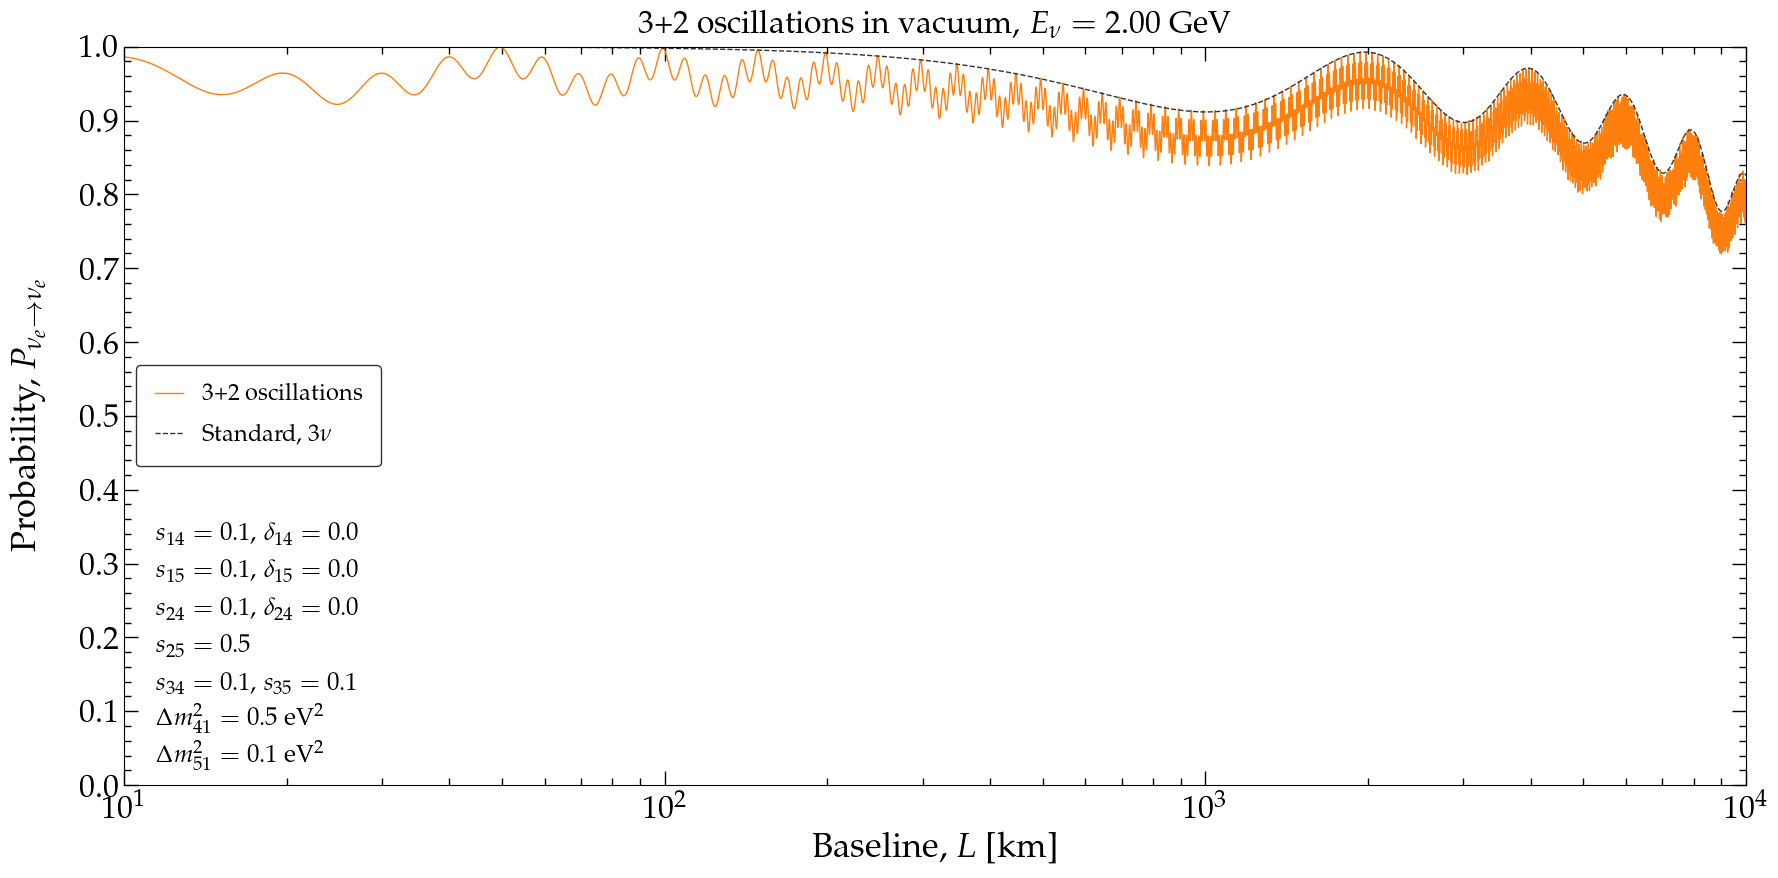

In [26]:
make_plot_prob_Nnu_3nu_vs_baseline(gd.NUE, gd.NUE, distances, prob_5nu_all, prob_3nu_all, N=2,
                                   title=r'3+2 oscillations in vacuum, $E_\nu = $~{:.2f}~GeV'.format(energy/gd.UNIT_GEV), save_plot=False)

### 4.3 Probabilities vs. energy

Generate probabilities

In [27]:
# Energies
energy_min, energy_max = 1.e0, 1.e2 # [GeV]
energy_npts = 5000
energies = np.logspace(np.log10(energy_min), np.log10(energy_max), energy_npts) # [GeV]

baseline = 5.e3 # [km]

# Standard, 3nu probabilities
H_3nu_vac_en_indep = hamiltonians.hamiltonian_3nu_vacuum_energy_independent(s12, s23, s13, dCP, D21, D31, 
                                                                               compute_matrix_multiplication=False) # Vacuum H without (1/E)
prob_3nu_all = np.array([oscprob.osc_prob(lambda l: (1/(enu*gd.UNIT_GEV))*H_3nu_vac_en_indep, 
                                          0.0, gd.CONV_KM_TO_INV_EV*baseline, 
                                          n_slabs=1, n_tpts_per_slab=10, magnus_exp_order=1) for enu in energies])

# 3+2 probabilities
H_5nu_vac_en_indep = hamiltonians.hamiltonian_5nu_vacuum_energy_independent(s12, s23, s13, dCP, s14, d14, s15, d15, s24, d24, s25, s34,
                                                                               s35, d35, D21, D31, D41, D51,
                                                                               compute_matrix_multiplication=False) 
prob_5nu_all = np.array([oscprob.osc_prob(lambda l: (1/(enu*gd.UNIT_GEV))*H_5nu_vac_en_indep, 
                                          0.0, gd.CONV_KM_TO_INV_EV*baseline, 
                                          n_slabs=1, n_tpts_per_slab=10, magnus_exp_order=1) for enu in energies])

(<Figure size 1800x900 with 1 Axes>,
 <Axes: title={'center': '3+2 oscillations in vacuum, $L = $~5000.00~km'}, xlabel='Neutrino energy, $E_\\nu$ [GeV]', ylabel='Probability,~$P_{\\nu_e \\to \\nu_e}$'>)

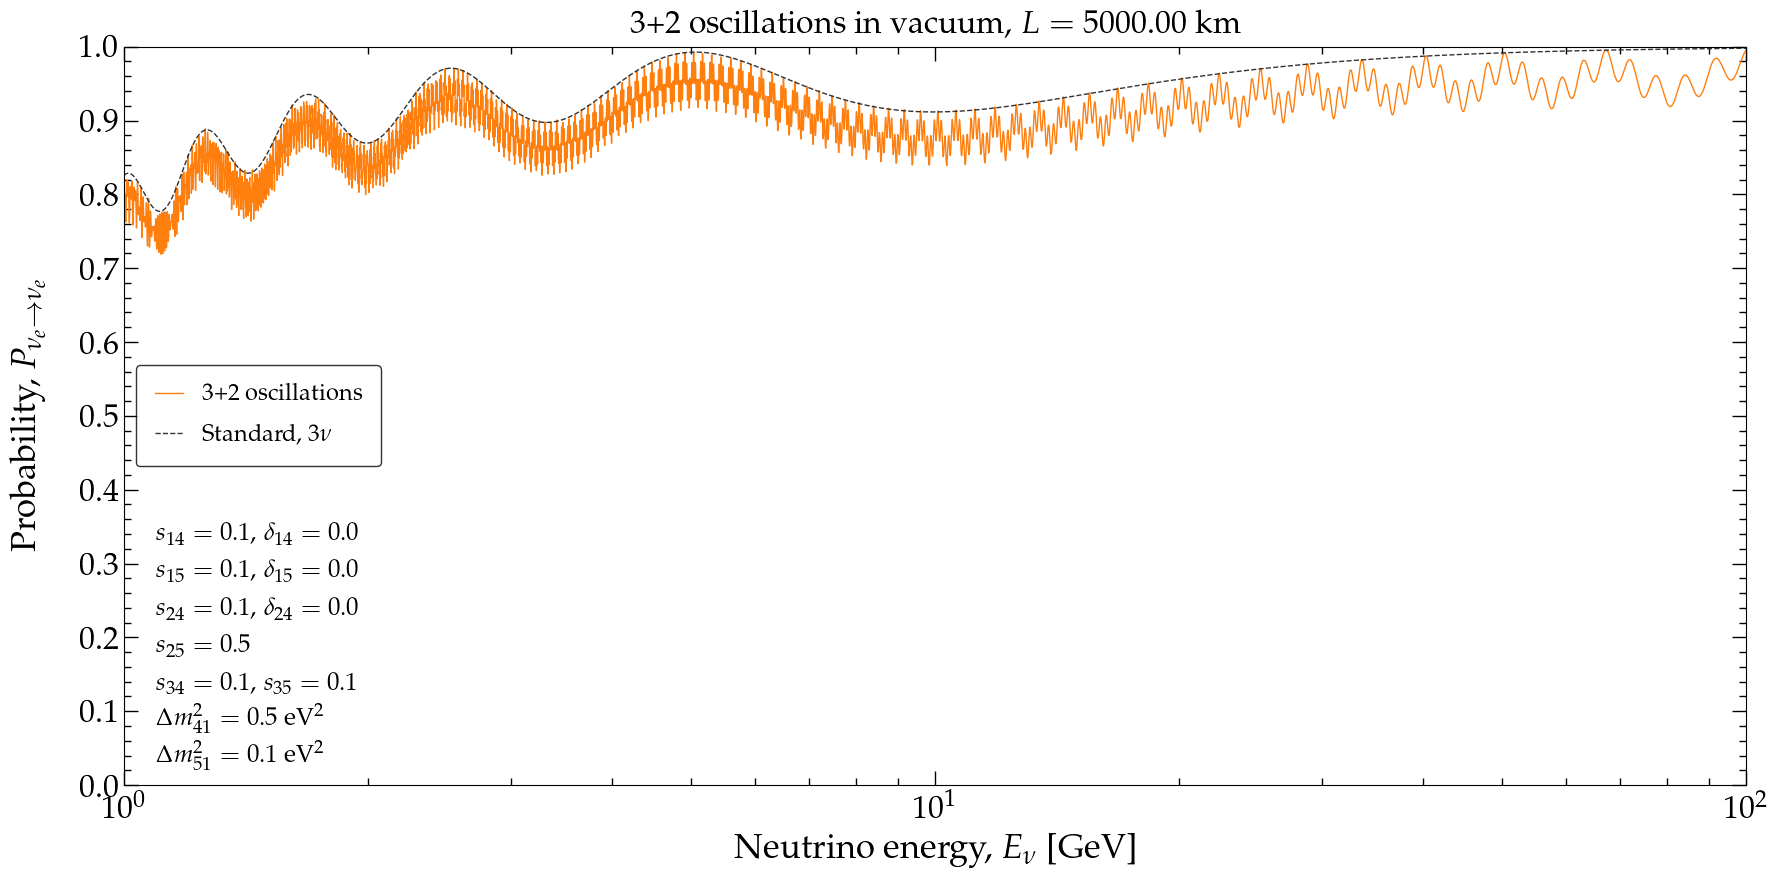

In [28]:
make_plot_prob_Nnu_3nu_vs_energy(gd.NUE, gd.NUE, energies, prob_5nu_all, prob_3nu_all, N=2,
                                 title=r'3+2 oscillations in vacuum, $L = $~{:.2f}~km'.format(baseline), save_plot=False)

---

**Previous:** [Oscillograms](06_magnus_oscillograms.ipynb)  
**Next:** [BSM: non-standard interactions](08_magnus_bsm_nsi.ipynb) --- a new matter potential in the same slot  
[API reference](https://mbustama.github.io/Magnus/functions.html) &middot; [Implementation details](https://mbustama.github.io/Magnus/implementation_details.html) &middot; [All notebooks](.)